In [4]:
pip install matplotlib


   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.8 MB 3.0 MB/s eta 0:00:03
   -------- ------------------------------- 1.6/7.8 MB 3.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/7.8 MB 2.9 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/7.8 MB 2.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/7.8 MB 2.7 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/7.8 MB 2.4 MB/s eta 0:00:02
   -------------------- ------------------- 3.9/7.8 MB 2.5 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/7.8 MB 2.5 MB/s eta 0:00:02
   ------------------------ --------------- 4.7/7.8 MB 2.4 MB/s eta 0:00:02
   ---------------------------- ----------- 5.5/7.8 MB 2.5 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/7.8 MB 2.5 MB/s eta 0:00:01
   -----------------------

In [3]:
# Import required libraries
from keras.models import load_model
from PIL import Image
import numpy as np

# Path to the image and model
image_path = '1012.png'
model_path = 'resnetbest20l.keras'

# Load the image
image = Image.open(image_path)


# Load the pre-trained model
model = load_model(model_path)

# Preprocess the image
image = image.resize((224, 224))  # Resize image to match the model's input size
image_array = np.array(image)  # Convert the image to a NumPy array
image_array = image_array / 255.0  # Normalize pixel values to [0, 1]

# Add a batch dimension to the image array
image_array = np.expand_dims(image_array, axis=0)

# Make prediction
predictions = model.predict(image_array)

# Print the predictions
predictions

1/1 [==============================] - 1s 799ms/step


array([[1.3894060e-01, 1.5532499e-06, 1.8172160e-02, 1.9207362e-05,
        1.2941809e-01, 3.1207914e-09, 9.9258136e-07, 4.0787674e-02,
        6.7265970e-01]], dtype=float32)

In [2]:
pip install pandas

   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
    --------------------------------------- 0.3/11.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.6 MB 2.2 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.6 MB 2.5 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/11.6 MB 2.5 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/11.6 MB 2.6 MB/s eta 0:00:04
   ---------- ----------------------------- 3.1/11.6 MB 2.7 MB/s eta 0:00:04
   ------------- -------------------------- 3.9/11.6 MB 2.9 MB/s eta 0:00:03
   ---------------- ----------------------- 4.7/11.6 MB 3.0 MB/s eta 0:00:03
   ------------------ --------------------- 5.2/11.6 MB 3.0 MB/s eta 0:00:03
   ------------------- -------------------- 5.8/11.6 MB 3.0 MB/s eta 0:00:02
   --------------------- ------------------ 6.3/11.6 MB 3.0 MB/s eta 0:00:02
   ---------------------- ----------------- 6.6/11.6 MB 3.0 MB/s eta 0:00:02
   ----------

In [2]:
pip install cv2

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [1]:
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
import copy
import math
import matplotlib

from shutil import copyfile
from time import time
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
import random
import shutil
import os
import gc
import glob
import json
import ast

print(keras.__version__)
np.random.seed(0)
random.seed(0)
tf.random.set_seed(0)

2.10.0


In [2]:
import pickle
with open("testpreprocessedData.pkl", 'rb') as f:
    data = pickle.load(f)

In [3]:
data.head()

,waferMap,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Center
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Center
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Center
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Center
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Center


In [4]:
data['waferMap'][0]

0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
0    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
Name: waferMap, dtype: object

In [12]:
classes = ["Center", "Donut", "Edge-Loc", "Edge-Ring", "Loc", "Near-full", "Random", "Scratch", "none"]
test = [0] * 9

for i in range(len(test)):
  test[i] = data[data['failureType'] == classes[i]]
  print(len(test[i]))
  test[i] = test[i].reset_index(drop = True)
  
print(sum(len(i) for i in test))

856
111
1008
1932
703
30
172
232
29006
34050


In [9]:
def normalize_and_convert(image):
    # Remove singleton dimension
    image_2d = image.squeeze(axis=2)
    
    # Normalize to [0, 255]
    min_val, max_val = image_2d.min(), image_2d.max()
    if max_val - min_val == 0:
        image_normalized = np.zeros_like(image_2d, dtype=np.uint8)
    else:
        image_normalized = ((image_2d - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    
    # Convert grayscale to RGB by stacking channels
    image_rgb = cv2.cvtColor(image_normalized, cv2.COLOR_GRAY2RGB)
    
    return image_rgb

In [10]:
import os
import numpy as np
import cv2


In [11]:
path = "WM811K_test"
for i in range(len(classes)):
    class_name = classes[i]
    class_dir = os.path.join(path, class_name)
    
    for j in range(len(test[i])):
        # Define the filename
        filename = f"{j}.png"
        file_path = os.path.join(class_dir, filename)
        
        # Print progress every 1000 images
        if j % 1000 == 0:
            print(f"Saving: {file_path}")
        
        # Extract the image
        image = test[i]['waferMap'].iloc[j]
        
        # Convert and normalize the image
        try:
            image_rgb = normalize_and_convert(image)
        except ValueError as e:
            print(f"Error processing image at class '{class_name}', index {j}: {e}")
            continue  # Skip this image and continue
        
        # Save the image using OpenCV
        success = cv2.imwrite(file_path, image_rgb)
        if not success:
            print(f"Failed to save image: {file_path}")

Saving: WM811K_test\Center\0.png
Error processing image at class 'Center', index 0: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 1: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 2: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 3: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 4: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 5: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 6: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 7: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 8: axis 2 is out of bounds for array of dimension 2
Error processing image at class 'Center', index 9: axis 2 is out of

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [7]:
import pickle
with open("finaltraindata.pkl", 'rb') as f:
    data_aug = pickle.load(f)

In [8]:
len(data_aug)

266947

In [9]:
classes = ["Center", "Donut", "Edge-Loc", "Edge-Ring", "Loc", "Near-full", "Random", "Scratch", "none"]
training_aug = [0] * 9

for i in range(len(training_aug)):
  training_aug[i] = data_aug[data_aug['failureType'] == classes[i]]
  print(len(training_aug[i]))
  training_aug[i] = training_aug[i].reset_index(drop = True)

17115
15000
20170
38640
15000
15000
15000
15000
116022


In [10]:
import pickle
with open("validation.pkl", 'rb') as f:
    validation = pickle.load(f)

In [11]:
len(validation)

27240

In [6]:
validation_set = [0] * 9

for i in range(len(validation_set)):
  validation_set[i] = validation[validation['failureType'] == classes[i]]
  print(len(validation_set[i]))
  validation_set[i] = validation_set[i].reset_index(drop = True)

685
89
807
1546
562
24
138
185
23204


In [ ]:
for i in range(len(validation_set)):
  for j in range(len(validation_set[i]['waferMap'])):
    validation_set[i]['waferMap'][j] = np.array(validation_set[i]['waferMap'][j]).tolist()

C:\Users\User\AppData\Local\Temp\ipykernel_18088\3310349766.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  validation_set[i]['waferMap'][j] = np.array(validation_set[i]['waferMap'][j]).tolist()


In [13]:
!rmdir /S /Q WM811K_train_aug

In [14]:
!mkdir WM811K_train_aug

In [15]:
path = "WM811K_train_aug"
for i in classes:
  os.mkdir(path+"/"+i)

In [22]:
import os
import numpy as np
import cv2

def normalize_and_convert(image):
    # Check if image has 3 channels or 1 channel
    if len(image.shape) == 3 and image.shape[2] == 1:
        # Remove singleton dimension
        image_2d = image.squeeze(axis=2)
    elif len(image.shape) == 2:
        # If the image is already 2D, use it directly
        image_2d = image
    else:
        raise ValueError("Invalid image shape")

    # Normalize to [0, 255]
    min_val, max_val = image_2d.min(), image_2d.max()
    if max_val - min_val == 0:
        image_normalized = np.zeros_like(image_2d, dtype=np.uint8)
    else:
        image_normalized = ((image_2d - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    
    # Convert grayscale to RGB by stacking channels
    image_rgb = cv2.cvtColor(image_normalized, cv2.COLOR_GRAY2RGB)
    
    return image_rgb

In [23]:
for i in range(len(classes)):
    class_name = classes[i]
    class_dir = os.path.join(path, class_name)
    
    for j in range(len(training_aug[i])):
        # Define the filename
        filename = f"{j}.png"
        file_path = os.path.join(class_dir, filename)
        
        # Print progress every 1000 images
        if j % 1000 == 0:
            print(f"Saving: {file_path}")
        
        # Extract the image
        image = training_aug[i]['waferMap'].iloc[j]
        
        # Convert and normalize the image
        try:
            image_rgb = normalize_and_convert(image)
        except ValueError as e:
            print(f"Error processing image at class '{class_name}', index {j}: {e}")
            continue  # Skip this image and continue
        
        # Save the image using OpenCV
        success = cv2.imwrite(file_path, image_rgb)
        if not success:
            print(f"Failed to save image: {file_path}")

Saving: WM811K_train_aug\Center\0.png
Saving: WM811K_train_aug\Center\1000.png
Saving: WM811K_train_aug\Center\2000.png
Saving: WM811K_train_aug\Center\3000.png
Saving: WM811K_train_aug\Center\4000.png
Saving: WM811K_train_aug\Center\5000.png
Saving: WM811K_train_aug\Center\6000.png
Saving: WM811K_train_aug\Center\7000.png
Saving: WM811K_train_aug\Center\8000.png
Saving: WM811K_train_aug\Center\9000.png
Saving: WM811K_train_aug\Center\10000.png
Saving: WM811K_train_aug\Center\11000.png
Saving: WM811K_train_aug\Center\12000.png
Saving: WM811K_train_aug\Center\13000.png
Saving: WM811K_train_aug\Center\14000.png
Saving: WM811K_train_aug\Center\15000.png
Saving: WM811K_train_aug\Center\16000.png
Saving: WM811K_train_aug\Center\17000.png
Saving: WM811K_train_aug\Donut\0.png
Saving: WM811K_train_aug\Donut\1000.png
Saving: WM811K_train_aug\Donut\2000.png
Saving: WM811K_train_aug\Donut\3000.png
Saving: WM811K_train_aug\Donut\4000.png
Saving: WM811K_train_aug\Donut\5000.png
Saving: WM811K_train

In [ ]:
import pickle
with open("testpreprocessedData.pkl", 'rb') as f:
    data = pickle.load(f)

In [ ]:
classes = ["Center", "Donut", "Edge-Loc", "Edge-Ring", "Loc", "Near-full", "Random", "Scratch", "none"]
test = [0] * 9

for i in range(len(test)):
  test[i] = data[data['failureType'] == classes[i]]
  print(len(test[i]))
  test[i] = test[i].reset_index(drop = True)
  
print(sum(len(i) for i in test))

In [24]:
path = "WM811K_test"
for i in range(len(classes)):
    class_name = classes[i]
    class_dir = os.path.join(path, class_name)
    
    for j in range(len(test[i])):
        # Define the filename
        filename = f"{j}.png"
        file_path = os.path.join(class_dir, filename)
        
        # Print progress every 1000 images
        if j % 1000 == 0:
            print(f"Saving: {file_path}")
        
        # Extract the image
        image = test[i]['waferMap'].iloc[j]
        
        # Convert and normalize the image
        try:
            image_rgb = normalize_and_convert(image)
        except ValueError as e:
            print(f"Error processing image at class '{class_name}', index {j}: {e}")
            continue  # Skip this image and continue
        
        # Save the image using OpenCV
        success = cv2.imwrite(file_path, image_rgb)
        if not success:
            print(f"Failed to save image: {file_path}")

Saving: WM811K_test\Center\0.png
Saving: WM811K_test\Donut\0.png
Saving: WM811K_test\Edge-Loc\0.png
Saving: WM811K_test\Edge-Loc\1000.png
Saving: WM811K_test\Edge-Ring\0.png
Saving: WM811K_test\Edge-Ring\1000.png
Saving: WM811K_test\Loc\0.png
Saving: WM811K_test\Near-full\0.png
Saving: WM811K_test\Random\0.png
Saving: WM811K_test\Scratch\0.png
Saving: WM811K_test\none\0.png
Saving: WM811K_test\none\1000.png
Saving: WM811K_test\none\2000.png
Saving: WM811K_test\none\3000.png
Saving: WM811K_test\none\4000.png
Saving: WM811K_test\none\5000.png
Saving: WM811K_test\none\6000.png
Saving: WM811K_test\none\7000.png
Saving: WM811K_test\none\8000.png
Saving: WM811K_test\none\9000.png
Saving: WM811K_test\none\10000.png
Saving: WM811K_test\none\11000.png
Saving: WM811K_test\none\12000.png
Saving: WM811K_test\none\13000.png
Saving: WM811K_test\none\14000.png
Saving: WM811K_test\none\15000.png
Saving: WM811K_test\none\16000.png
Saving: WM811K_test\none\17000.png
Saving: WM811K_test\none\18000.png
Sa

In [25]:
# The function returns a tuple with two lists, one with the batches of the images, 
# the other with the relative batches of the ground_truth.

def from_DataBatch_to_list(dataBatch):
  val_dataset2 = [] 
  val_dataset2_gt = []
  i=0

  for batch in dataBatch:
    for i in range(len(batch)):
      if (i==0):
        val_dataset2.append(batch[i])
      if(i==1):
        val_dataset2_gt.append(batch[i])
    
  return (val_dataset2, val_dataset2_gt)

In [26]:
# Input: tuple with 2 lists, obtained from the from_DataBatch_to_list function

def topk_accuracy(model, k, validationTuple):
  val_dataset = validationTuple[0]
  val_dataset_gt = validationTuple[1]

  # TopK accuracy metric
  m = keras.metrics.TopKCategoricalAccuracy( 
        k=k, 
        name='top_k_categorical_accuracy', 
        dtype=None
      )

  # We iterate over the individual batches
  for i in range(len(val_dataset)):
    prediction = model.predict(val_dataset[i])
    # Let's convert prediction in a tensor
    prediction = tf.convert_to_tensor(prediction)
    # Now we update the metric with respect to the current batch 
    m.update_state(val_dataset_gt[i], prediction)
  
  return m.result().numpy()

In [27]:
def confusion_matrix(model, failure_types, validationTuple, threshold):
  precision = []
  recall = []

  val_dataset = validationTuple[0]
  val_dataset_gt = validationTuple[1]

  if (len(threshold)!=0):
    # We determine the predicted class for each data in the validation-set and build 
    # the corresponding list containing the ground truth
    for i in range(len(val_dataset)): 
      if i == 0:
        prediction = model.predict(val_dataset[i])
        prediction_gt = list(map(lambda x: np.asarray(x).argmax(), val_dataset_gt[i]))
        # We determine the predicted class
        predicted_class = list(map(lambda x: x[:8].argmax(), prediction))
        # We store the probability value for the predicted class
        predicted_class_probability = list(map(lambda x: x[:8].max(), prediction))

      prediction = model.predict(val_dataset[i])
      prediction_gt.extend(list(map(lambda x: np.asarray(x).argmax(), val_dataset_gt[i])))
      # We determine the predicted class
      predicted_class.extend(list(map(lambda x: x[:8].argmax(), prediction)))
      # We store the probability value for the predicted class
      predicted_class_probability.extend(list(map(lambda x: x[:8].max(), prediction)))

    # We calculate the confusion matrix for each threshold
    cm = []
    for l in range(len(threshold)):
      cm.append([[0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0]])

      for i in range(len(failure_types)):
        for j in range(len(prediction_gt)):
          if (prediction_gt[j] == i):
            # If the predicted value does not exceed the threshold we classify the item as a negative class
            if (predicted_class_probability[j]<=threshold[l]):
                  cm[l][i][8] += 1
            else:
              for k in range(len(failure_types)):
                if (predicted_class[j] == k):
                  cm[l][i][k] += 1

    return cm

  else:
    # We determine the predicted class for each data in the validation-set and build 
    # the corresponding list containing the ground truth
    for i in range(len(val_dataset)):
      if i == 0:
        prediction = model.predict(val_dataset[i])
        prediction_gt = list(map(lambda x: np.asarray(x).argmax(), val_dataset_gt[i]))
        # We determine the predicted class
        predicted_class = list(map(lambda x: x.argmax(), prediction))

      prediction = model.predict(val_dataset[i])
      prediction_gt.extend(list(map(lambda x: np.asarray(x).argmax(), val_dataset_gt[i])))
      # We determine the predicted class
      predicted_class.extend(list(map(lambda x: x.argmax(), prediction)))

    # We calculate the confusion matrix for each threshold
    cm = [[0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0],
              [0,0,0,0,0,0,0,0,0]]

    for i in range(len(failure_types)):
      for j in range(len(prediction_gt)):
        if (prediction_gt[j] == i):
          for k in range(len(failure_types)):
            if (predicted_class[j] == k):
              cm[i][k] += 1

    return cm

In [28]:
def classes_proportion_correctly_classified(c_matrix, failure_types):
  dict_ = {}
  for i in range(len(failure_types)):
    dict_[failure_types[i]] = c_matrix[i][i]/np.sum(c_matrix[i])
  
  return dict_

In [29]:
def metrics_report(c_matrix):
  precision = 0
  recall = 0

  num = 0
  precision_den = 0
  recall_den = 0

  for i in range(len(c_matrix)):
  # Index 8 is assumed to represent the negative class
    if (i != 8):
      num += c_matrix[i][i]
      precision_den += c_matrix[i][i] + c_matrix[8][i]
      recall_den += c_matrix[i][i] + c_matrix[i][8]
    

  precision = num/precision_den
  recall = num/recall_den
  return (
      {'precision': precision, 
       'recall': recall,
       'f1-measure': 2*(precision*recall)/(precision+recall)})

In [30]:
def roc_auc_report(confusion_matrixes):
  tp_rates = []
  fp_rates = []

  for l in range(len(confusion_matrixes)):
    tp = 0; fn = 0
    fp = 0; tn = 0

    cm = confusion_matrixes[l]

    for i in range(len(cm)):
      if (i != 8):
        tp += cm[i][i] 
        fn += cm[i][8]
        fp += cm[8][i]
      
      if (i == 8):
        tn = cm[i][i]
  
    tp_rates.append(tp/(tp+fn))
    fp_rates.append(fp/(fp+tn))

  return (tp_rates, fp_rates)

In [31]:
def roc_curve(tp_rates, fp_rates):
  tp = copy.deepcopy(tp_rates)
  #tp.extend([0])
  tp.reverse()

  fp = copy.deepcopy(fp_rates)
  #fp.extend([0])
  fp.reverse()

  plt.plot(fp, tp)
  plt.plot([0, 1], ls="--")
  plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
  plt.xlabel("false positive rate") 
  plt.ylabel("true positive rate")
  plt.title("ROC curve")

In [102]:
import os
import shutil
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Define your paths
val_path = 'WM811K_val'
test_path = 'WM811K_test'

# Load the validation dataset to get class names
craft_dataset = image_dataset_from_directory(val_path,
                                            image_size=(224, 224),
                                            color_mode='rgb',
                                            batch_size=32,
                                            label_mode='categorical',
                                            shuffle=True,
                                            seed=1)

# Iterate over each class name (category) and move corresponding images
for class_name in val_dataset.class_names:
    # Define the source and destination directories for each class
    val_class_dir = os.path.join(val_path, class_name)
    test_class_dir = os.path.join(test_path, class_name)
    
    # Make sure the test class directory exists, if not, create it
    if not os.path.exists(test_class_dir):
        os.makedirs(test_class_dir)

    # Loop through all files in the val class directory
    for filename in os.listdir(val_class_dir):
        # Define full paths for source and destination
        val_file_path = os.path.join(val_class_dir, filename)
        
        # Create a new file name with a prefix 'val_' to avoid overwriting
        new_filename = 'val_' + filename
        new_test_file_path = os.path.join(test_class_dir, new_filename)

        # Check if the new file name already exists in the test folder
        if not os.path.exists(new_test_file_path):
            # Renaming happens here before the copy operation
            shutil.copy(val_file_path, new_test_file_path)
            print(f"Copied and renamed {filename} to {new_test_file_path}")
        else:
            # If the file already exists, print a message and skip it
            print(f"File {new_filename} already exists in {test_class_dir}, skipping.")




Found 27240 files belonging to 9 classes.
Copied and renamed 0.png to WM811K_test\Center\val_0.png
Copied and renamed 1.png to WM811K_test\Center\val_1.png
Copied and renamed 10.png to WM811K_test\Center\val_10.png
Copied and renamed 100.png to WM811K_test\Center\val_100.png
Copied and renamed 101.png to WM811K_test\Center\val_101.png
Copied and renamed 102.png to WM811K_test\Center\val_102.png
Copied and renamed 103.png to WM811K_test\Center\val_103.png
Copied and renamed 104.png to WM811K_test\Center\val_104.png
Copied and renamed 105.png to WM811K_test\Center\val_105.png
Copied and renamed 106.png to WM811K_test\Center\val_106.png
Copied and renamed 107.png to WM811K_test\Center\val_107.png
Copied and renamed 108.png to WM811K_test\Center\val_108.png
Copied and renamed 109.png to WM811K_test\Center\val_109.png
Copied and renamed 11.png to WM811K_test\Center\val_11.png
Copied and renamed 110.png to WM811K_test\Center\val_110.png
Copied and renamed 111.png to WM811K_test\Center\val_11

In [116]:
import os
import shutil
import random

def copy_specific_files_with_rename(source_folder, dest_folder, num_files_to_copy):
    """
    Copy a specific number of files from source_folder to dest_folder, renaming if conflicts occur.
    """
    # Ensure the destination folder exists
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    # List all files in the source folder
    source_files = os.listdir(source_folder)

    # Make sure we don't try to copy more files than exist in the source folder
    num_files_to_copy = min(num_files_to_copy, len(source_files))

    # Randomly choose the specified number of files
    files_to_copy = random.sample(source_files, num_files_to_copy)

    for filename in files_to_copy:
        # Define the full path of the source and destination files
        source_file_path = os.path.join(source_folder, filename)
        dest_file_path = os.path.join(dest_folder, filename)

        # Check if the file already exists in the destination folder
        if os.path.exists(dest_file_path):
            # Handle name conflict by renaming the file
            base_name, ext = os.path.splitext(filename)
            counter = 1
            # Generate a new filename by adding a counter suffix
            while os.path.exists(dest_file_path):
                new_filename = f"aug{base_name}_{counter}{ext}"
                dest_file_path = os.path.join(dest_folder, new_filename)
                counter += 1

        # Copy the file to the destination folder (renamed if necessary)
        shutil.copy(source_file_path, dest_file_path)
        print(f"Copied {filename} to {dest_file_path}")

# Example usage
source_folder = 'WM811K_train_aug/Loc'
dest_folder = 'WM811K_test/Loc'
num_files_to_copy = 1500  # Specify the number of files you want to copy

copy_specific_files_with_rename(source_folder, dest_folder, num_files_to_copy)


Copied 10754.png to WM811K_test/Loc\10754.png
Copied 973.png to WM811K_test/Loc\973.png
Copied 5054.png to WM811K_test/Loc\5054.png
Copied 8580.png to WM811K_test/Loc\8580.png
Copied 1109.png to WM811K_test/Loc\1109.png
Copied 10997.png to WM811K_test/Loc\10997.png
Copied 7285.png to WM811K_test/Loc\7285.png
Copied 11595.png to WM811K_test/Loc\11595.png
Copied 2005.png to WM811K_test/Loc\2005.png
Copied 14066.png to WM811K_test/Loc\14066.png
Copied 206.png to WM811K_test/Loc\aug206_1.png
Copied 4844.png to WM811K_test/Loc\4844.png
Copied 2063.png to WM811K_test/Loc\2063.png
Copied 4005.png to WM811K_test/Loc\4005.png
Copied 4452.png to WM811K_test/Loc\4452.png
Copied 6804.png to WM811K_test/Loc\6804.png
Copied 733.png to WM811K_test/Loc\733.png
Copied 5691.png to WM811K_test/Loc\5691.png
Copied 8984.png to WM811K_test/Loc\8984.png
Copied 2764.png to WM811K_test/Loc\2764.png
Copied 12321.png to WM811K_test/Loc\12321.png
Copied 3589.png to WM811K_test/Loc\3589.png
Copied 11733.png to WM8

In [139]:
train_path = 'WM811K_train'
train_dataset = keras.preprocessing.image_dataset_from_directory(train_path,
                                                            image_size = (224, 224),
                                                            color_mode = 'rgb',
                                                            batch_size = 32,
                                                            label_mode = 'categorical',
                                                            shuffle = True,
                                                            seed = 1)

val_path = 'WM811K_val'
val_dataset = keras.preprocessing.image_dataset_from_directory(val_path,
                                                            image_size = (224, 224),
                                                            color_mode = 'rgb',
                                                            batch_size = 32,
                                                            label_mode = 'categorical',
                                                            shuffle = True,
                                                            seed = 1)

test_path = 'WM811K_test'
test_dataset = keras.preprocessing.image_dataset_from_directory(test_path,
                                                            image_size = (224, 224),
                                                            color_mode = 'rgb',
                                                            batch_size = 32,
                                                            label_mode = 'categorical',
                                                            shuffle = True,
                                                            seed = 1)

train_aug_path = 'WM811K_train_aug'
train_aug_dataset = keras.preprocessing.image_dataset_from_directory(train_aug_path,
                                                            image_size = (224,224),
                                                            color_mode = 'rgb',
                                                            batch_size = 32,
                                                            label_mode = 'categorical',
                                                            shuffle = True,
                                                            seed = 1)


Found 108956 files belonging to 9 classes.
Found 27240 files belonging to 9 classes.
Found 26480 files belonging to 9 classes.
Found 133115 files belonging to 9 classes.


In [106]:
import os
import random
import shutil

# Define paths
train_aug_path = 'WM811K_test'
category_to_remove = 'Edge-Ring'  # Replace with the actual category name you want to remove images from

# Path to the folder of the category you want to remove images from
category_folder_path = os.path.join(train_aug_path, category_to_remove)

# List all files in the category folder
image_files = os.listdir(category_folder_path)

# Specify the number of images to remove (e.g., remove 5 random images)
num_images_to_remove = 500 # Adjust this to your desired number

# Ensure we don't try to remove more images than exist in the category
num_images_to_remove = min(num_images_to_remove, len(image_files))

# Randomly select a subset of images to remove
images_to_remove = random.sample(image_files, num_images_to_remove)

# Remove the selected images
for image in images_to_remove:
    image_path = os.path.join(category_folder_path, image)
    
    # Remove the image file
    os.remove(image_path)
    print(f"Removed {image_path}")


Removed WM811K_test\Edge-Ring\1003.png
Removed WM811K_test\Edge-Ring\229.png
Removed WM811K_test\Edge-Ring\val_10.png
Removed WM811K_test\Edge-Ring\1161.png
Removed WM811K_test\Edge-Ring\val_607.png
Removed WM811K_test\Edge-Ring\24.png
Removed WM811K_test\Edge-Ring\val_648.png
Removed WM811K_test\Edge-Ring\val_1184.png
Removed WM811K_test\Edge-Ring\720.png
Removed WM811K_test\Edge-Ring\val_1324.png
Removed WM811K_test\Edge-Ring\1080.png
Removed WM811K_test\Edge-Ring\524.png
Removed WM811K_test\Edge-Ring\63.png
Removed WM811K_test\Edge-Ring\297.png
Removed WM811K_test\Edge-Ring\val_182.png
Removed WM811K_test\Edge-Ring\val_1291.png
Removed WM811K_test\Edge-Ring\val_653.png
Removed WM811K_test\Edge-Ring\1524.png
Removed WM811K_test\Edge-Ring\834.png
Removed WM811K_test\Edge-Ring\87.png
Removed WM811K_test\Edge-Ring\val_162.png
Removed WM811K_test\Edge-Ring\1191.png
Removed WM811K_test\Edge-Ring\1502.png
Removed WM811K_test\Edge-Ring\712.png
Removed WM811K_test\Edge-Ring\cval_2953.png
Rem

In [118]:
# Print the category names
print("Category Names:", train_aug_dataset.class_names)

# Count the number of images per category
category_counts = {}
for images, labels in train_aug_dataset:
    for label in labels.numpy():
        category = train_aug_dataset.class_names[label.argmax()]
        if category in category_counts:
            category_counts[category] += 1
        else:
            category_counts[category] = 1

# Print image counts per category
print("\nImage Count per Category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


Category Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Image Count per Category:
Donut: 15000
none: 13000
Near-full: 15000
Edge-Ring: 15000
Loc: 15000
Center: 15115
Scratch: 15000
Random: 15000
Edge-Loc: 15000


In [70]:
# Print the category names
print("Category Names:", train_dataset.class_names)

# Count the number of images per category
category_counts = {}
for images, labels in train_dataset:
    for label in labels.numpy():
        category = train_dataset.class_names[label.argmax()]
        if category in category_counts:
            category_counts[category] += 1
        else:
            category_counts[category] = 1

# Print image counts per category
print("\nImage Count per Category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


Category Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Image Count per Category:
none: 92818
Edge-Ring: 6182
Loc: 2249
Center: 2738
Near-full: 95
Donut: 355
Scratch: 742
Edge-Loc: 3227
Random: 550


In [119]:
# Print the category names
print("Category Names:", test_dataset.class_names)

# Count the number of images per category
category_counts = {}
for images, labels in test_dataset:
    for label in labels.numpy():
        category = test_dataset.class_names[label.argmax()]
        if category in category_counts:
            category_counts[category] += 1
        else:
            category_counts[category] = 1

# Print image counts per category
print("\nImage Count per Category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")

Category Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Image Count per Category:
none: 3000
Loc: 2865
Edge-Loc: 2915
Near-full: 2854
Edge-Ring: 3078
Random: 2910
Center: 3041
Scratch: 3017
Donut: 2800


In [72]:
# Print the category names
print("Category Names:", val_dataset.class_names)

# Count the number of images per category
category_counts = {}
for images, labels in val_dataset:
    for label in labels.numpy():
        category = val_dataset.class_names[label.argmax()]
        if category in category_counts:
            category_counts[category] += 1
        else:
            category_counts[category] = 1

# Print image counts per category
print("\nImage Count per Category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")

Category Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Image Count per Category:
none: 23204
Edge-Ring: 1546
Scratch: 185
Loc: 562
Edge-Loc: 807
Center: 685
Donut: 89
Random: 138
Near-full: 24


In [7]:
!pip install scikit-learn


   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.0 MB 2.8 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/11.0 MB 3.1 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/11.0 MB 3.0 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/11.0 MB 3.0 MB/s eta 0:00:03
   -------------- ------------------------- 3.9/11.0 MB 3.3 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/11.0 MB 3.3 MB/s eta 0:00:03
   ------------------- -------------------- 5.2/11.0 MB 3.3 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.0 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.0 MB 3.3 MB/s eta 0:00:02
   ------------------------- -------------- 7.1/11.0 MB 3.4 MB/s eta 0:00:02
   ---------------------------- ----------- 7.9/11.0 MB 3.4 MB/s eta 0:00:01
   ----------

In [1]:
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
import math
from time import time
import pandas as pd
import numpy as np

import random

import os

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from keras.regularizers import l2 
from keras.callbacks import ReduceLROnPlateau

In [1]:
import tensorflow as tf
from tensorflow import keras

batch_size = 32
img_height = 224
img_width = 224
seed = 123
train_dir = 'WM811K_train_split'
val_dir = 'WM811K_val_split'
# Load Training Dataset
train_dataset = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=(img_height, img_width),
    shuffle=True,
    seed=seed
)

# Load Validation Dataset
val_dataset = keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=(img_height, img_width),
    shuffle=False,
    seed=seed
)

# Verify class names
print("Training Dataset Class Names:", train_dataset.class_names)
print("Validation Dataset Class Names:", val_dataset.class_names)

Found 106492 files belonging to 9 classes.
Found 26623 files belonging to 9 classes.
Training Dataset Class Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
Validation Dataset Class Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


In [5]:
# Print the category names
print("Category Names:", val_dataset.class_names)

# Count the number of images per category
category_counts = {}
for images, labels in val_dataset:
    for label in labels.numpy():
        category = val_dataset.class_names[label.argmax()]
        if category in category_counts:
            category_counts[category] += 1
        else:
            category_counts[category] = 1

# Print image counts per category
print("\nImage Count per Category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")

Category Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Image Count per Category:
Center: 3023
Donut: 3000
Edge-Loc: 3000
Edge-Ring: 3000
Loc: 3000
Near-full: 3000
Random: 3000
Scratch: 3000
none: 2600


In [6]:
# Print the category names
print("Category Names:", train_dataset.class_names)

# Count the number of images per category
category_counts = {}
for images, labels in train_dataset:
    for label in labels.numpy():
        category = train_dataset.class_names[label.argmax()]
        if category in category_counts:
            category_counts[category] += 1
        else:
            category_counts[category] = 1

# Print image counts per category
print("\nImage Count per Category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")

Category Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Image Count per Category:
Center: 12092
Donut: 12000
Loc: 12000
Edge-Loc: 12000
Edge-Ring: 12000
Scratch: 12000
Random: 12000
none: 10400
Near-full: 12000


In [11]:
from tensorflow.keras import layers
from tensorflow.keras import callbacks

# Define the number of classes
num_classes = 9

# Input layer
inputs = keras.Input(shape=(224, 224, 3))

# He Normal initializer
he_init = tf.keras.initializers.HeNormal(seed=42)

# Block 1: Conv -> BN -> ReLU -> MaxPool
x = layers.Conv2D(32, kernel_size=3, padding='same', kernel_initializer=he_init)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=2, padding='same')(x)

# Block 2: Conv -> BN -> ReLU -> MaxPool
x = layers.Conv2D(64, kernel_size=3, padding='same', kernel_initializer=he_init)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=2, padding='same')(x)

# Block 3: Conv -> BN -> ReLU -> Global Pool
x = layers.Conv2D(128, kernel_size=3, padding='same', kernel_initializer=he_init)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling2D()(x)

# Fully Connected Layers
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Output layer
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Define the model
modelcustom = keras.Model(inputs, outputs)

# Compile the model with an optimized optimizer
modelcustom.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Define callbacks
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ModelCheckpoint('custom_model.keras', monitor='val_loss', save_best_only=True, mode='min')
]


In [12]:
# Train the model
hcustom = modelcustom.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks_list
)

Epoch 1/20
3328/3328 [==============================] - 144s 43ms/step - loss: 0.8660 - accuracy: 0.6782 - val_loss: 0.6639 - val_accuracy: 0.7652
Epoch 2/20
3328/3328 [==============================] - 142s 43ms/step - loss: 0.6516 - accuracy: 0.7608 - val_loss: 0.5313 - val_accuracy: 0.8069
Epoch 3/20
3328/3328 [==============================] - 142s 43ms/step - loss: 0.5653 - accuracy: 0.7939 - val_loss: 0.5152 - val_accuracy: 0.8081
Epoch 4/20
3328/3328 [==============================] - 142s 43ms/step - loss: 0.5153 - accuracy: 0.8110 - val_loss: 0.4879 - val_accuracy: 0.8176
Epoch 5/20
3328/3328 [==============================] - 142s 43ms/step - loss: 0.4815 - accuracy: 0.8222 - val_loss: 0.5049 - val_accuracy: 0.8169
Epoch 6/20
3328/3328 [==============================] - 142s 43ms/step - loss: 0.4565 - accuracy: 0.8316 - val_loss: 0.4169 - val_accuracy: 0.8416
Epoch 7/20
3328/3328 [==============================] - 143s 43ms/step - loss: 0.4365 - accuracy: 0.8366 - val_loss: 0

In [13]:
# Extract true labels from the validation dataset
y_true = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)
y_true = np.argmax(y_true, axis=1)

# Generate predictions
y_pred_probs = modelcustom.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Verify unique classes in y_true and y_pred
unique_y_true = np.unique(y_true)
unique_y_pred = np.unique(y_pred)

print(f"Unique classes in y_true: {unique_y_true}")
print(f"Unique classes in y_pred: {unique_y_pred}")

832/832 [==============================] - 10s 12ms/step
Unique classes in y_true: [0 1 2 3 4 5 6 7 8]
Unique classes in y_pred: [0 1 2 3 4 5 6 7 8]


In [14]:
# Extract true labels from the validation dataset
y_true = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)
y_true = np.argmax(y_true, axis=1)

# Generate predictions
y_pred_probs = modelcustom.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Verify unique classes in y_true and y_pred
unique_y_true = np.unique(y_true)
unique_y_pred = np.unique(y_pred)

print(f"Unique classes in y_true: {unique_y_true}")
print(f"Unique classes in y_pred: {unique_y_pred}")


accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')  # 'micro' or 'weighted' also possible
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8621
Precision: 0.8758
Recall: 0.8641
F1 Score: 0.8624


In [27]:
# Save the history with pickle
with open('historycustom.pkl', 'wb') as f:
    pickle.dump(hcustom.history, f)

In [128]:
class_names = train_aug_dataset.class_names

In [131]:
y_true = np.concatenate([y.numpy() for x, y in train_aug_dataset], axis=0)
y_pred_probs = modelcustom.predict(train_aug_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_true, axis=1)

# 12. Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

4160/4160 [==============================] - 54s 13ms/step
Classification Report:

              precision    recall  f1-score   support

      Center       0.11      0.10      0.11     15115
       Donut       0.12      0.11      0.12     15000
    Edge-Loc       0.11      0.14      0.13     15000
   Edge-Ring       0.12      0.12      0.12     15000
         Loc       0.12      0.11      0.11     15000
   Near-full       0.12      0.12      0.12     15000
      Random       0.12      0.12      0.12     15000
     Scratch       0.12      0.11      0.11     15000
        none       0.10      0.10      0.10     13000

    accuracy                           0.11    133115
   macro avg       0.11      0.11      0.11    133115
weighted avg       0.11      0.11      0.11    133115



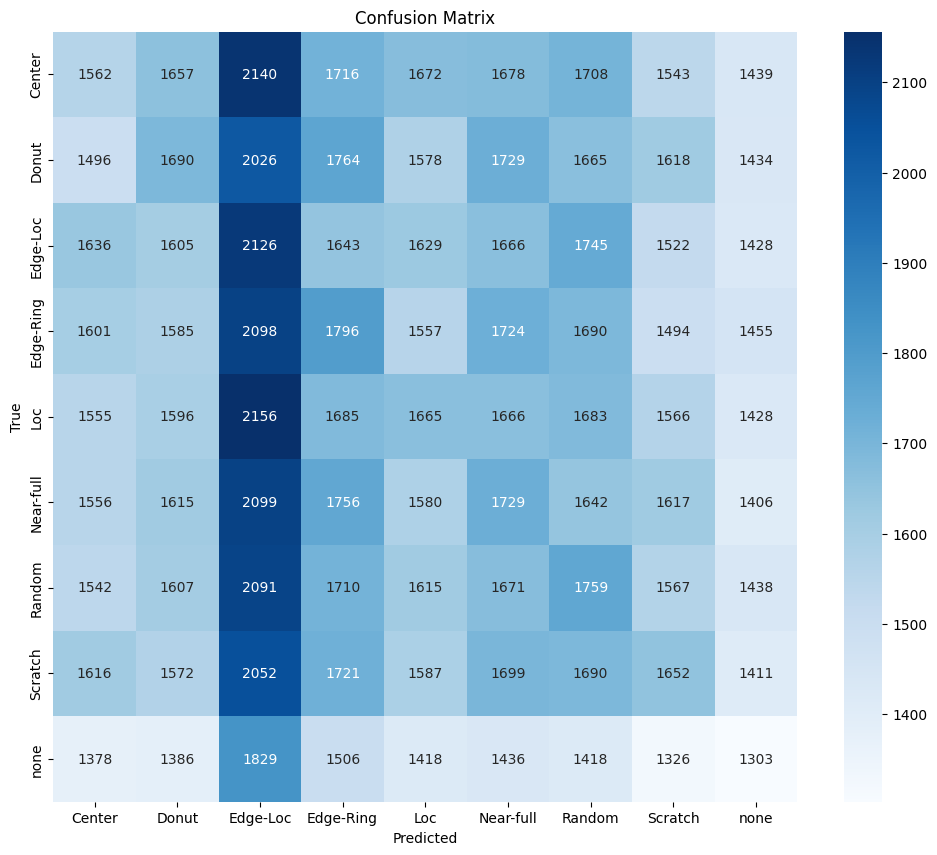

In [132]:
# 13. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

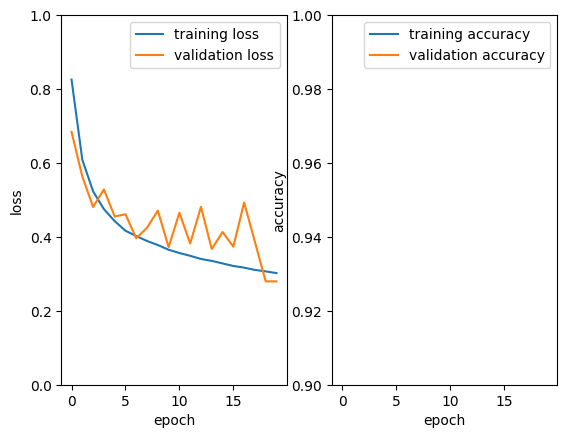

In [134]:
plt.subplot(1,2,1)
plt.plot(hcustom.history['loss'])
plt.plot(hcustom.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.ylim([0, 1])
plt.legend(['training loss', 'validation loss'])

plt.subplot(1,2,2)
plt.plot(hcustom.history['accuracy'])
plt.plot(hcustom.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.ylim([0.9, 1])
plt.legend(['training accuracy', 'validation accuracy'])
# plt.savefig('CUSTOM_training_loss_curve.png', dpi=300)

In [2]:
# Define paths
data_dir = 'WM811K_train_aug'  # Updated directory containing all classes

# Parameters
batch_size = 32
img_height = 224
img_width = 224
validation_split = 0.2  # 20% for validation
seed = 123

# Create Training Dataset
train_dataset = keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=True
)

# Create Validation Dataset
validation_dataset = keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False
)

# Print Class Names
print("Class Names:", train_dataset.class_names)

# Verify the Split
train_count = 0
for images, labels in train_dataset:
    train_count += images.shape[0]
print(f"\nTraining Images: {train_count}")

val_count = 0
for images, labels in validation_dataset:
    val_count += images.shape[0]
print(f"Validation Images: {val_count}")

Found 133115 files belonging to 9 classes.
Using 106492 files for training.
Found 133115 files belonging to 9 classes.
Using 26623 files for validation.
Class Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Training Images: 106492
Validation Images: 26623


In [175]:
############################## ResNet50 Model FineTUNED + ################################

from tensorflow.keras.applications import ResNet50



# Load ResNet50 base model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model initially

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)  # Dropout to reduce overfitting
x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)
predictions = Dense(len(train_aug_dataset.class_names), activation='softmax')(x)

# Create the final model
resnet0 = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
resnet0.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# Compute class weights to handle class imbalance
y_train_classes = np.concatenate([y.numpy() for _, y in train_aug_dataset])
y_train_labels = np.argmax(y_train_classes, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights))

# Callbacks for training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint('resnetbest20l.keras', monitor='val_loss', save_best_only=True, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

# Train only the top layers (before fine-tuning)
hres020l = resnet0.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights
)




Epoch 1/10
3328/3328 [==============================] - 144s 43ms/step - loss: 1.5339 - accuracy: 0.7577 - val_loss: 0.9389 - val_accuracy: 0.7919 - lr: 0.0010
Epoch 2/10
3328/3328 [==============================] - 140s 42ms/step - loss: 0.9043 - accuracy: 0.7816 - val_loss: 0.7750 - val_accuracy: 0.8095 - lr: 0.0010
Epoch 3/10
3328/3328 [==============================] - 139s 42ms/step - loss: 0.8036 - accuracy: 0.7924 - val_loss: 0.7152 - val_accuracy: 0.8158 - lr: 0.0010
Epoch 4/10
3328/3328 [==============================] - 140s 42ms/step - loss: 0.7581 - accuracy: 0.7968 - val_loss: 0.6559 - val_accuracy: 0.8236 - lr: 0.0010
Epoch 5/10
3328/3328 [==============================] - 140s 42ms/step - loss: 0.7291 - accuracy: 0.8010 - val_loss: 0.6316 - val_accuracy: 0.8296 - lr: 0.0010
Epoch 6/10
3328/3328 [==============================] - 141s 42ms/step - loss: 0.7156 - accuracy: 0.8015 - val_loss: 0.6285 - val_accuracy: 0.8257 - lr: 0.0010
Epoch 7/10
3328/3328 [==================

In [176]:
# Unfreeze some layers in the base model for fine-tuning
base_model.trainable = True
# Freeze all layers except the last 5
for layer in base_model.layers[:-15]:
    layer.trainable = False

# Recompile the model with a lower learning rate for fine-tuning
resnet0.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Fine-tune the model
historyfineres20l = resnet0.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    # Remove batch_size if train_aug_dataset is already batched
    callbacks=callbacks,
    class_weight=class_weights
)

# Evaluate on the test dataset
test_loss, test_accuracy = resnet0.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/15
3328/3328 [==============================] - 154s 45ms/step - loss: 0.4834 - accuracy: 0.8605 - val_loss: 0.3304 - val_accuracy: 0.8996 - lr: 1.0000e-04
Epoch 2/15
3328/3328 [==============================] - 151s 45ms/step - loss: 0.3035 - accuracy: 0.9085 - val_loss: 0.2605 - val_accuracy: 0.9165 - lr: 1.0000e-04
Epoch 3/15
3328/3328 [==============================] - 149s 45ms/step - loss: 0.2417 - accuracy: 0.9248 - val_loss: 0.2339 - val_accuracy: 0.9241 - lr: 1.0000e-04
Epoch 4/15
3328/3328 [==============================] - 150s 45ms/step - loss: 0.2011 - accuracy: 0.9386 - val_loss: 0.2080 - val_accuracy: 0.9326 - lr: 1.0000e-04
Epoch 5/15
3328/3328 [==============================] - 149s 45ms/step - loss: 0.1696 - accuracy: 0.9484 - val_loss: 0.2242 - val_accuracy: 0.9288 - lr: 1.0000e-04
Epoch 6/15
3328/3328 [==============================] - 149s 45ms/step - loss: 0.1437 - accuracy: 0.9567 - val_loss: 0.2123 - val_accuracy: 0.9349 - lr: 1.0000e-04
Epoch 7/15
3328/

In [38]:
pip install tensorflow-gpu


  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [44 lines of output]
  Traceback (most recent call last):
    File "C:\Users\User\anaconda3\Lib\site-packages\packaging\requirements.py", line 36, in __init__
      parsed = _parse_requirement(requirement_string)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\User\anaconda3\Lib\site-packages\packaging\_parser.py", line 62, in parse_requirement
      return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\User\anaconda3\Lib\site-packages\packaging\_parser.py", line 80, in _parse_requirement
      url, specifier, marker = _parse_requirement_details(tokenizer)
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\User\anaconda3\Lib\site-packages\packaging\_parser.py", line 124, in _parse_requirement_details
      marke

In [5]:
import tensorflow as tf

# Check if TensorFlow detects any GPUs
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# List details of the GPUs available (if any)
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    print(f"Device name: {gpu.name}")

Num GPUs Available:  1
Device name: /physical_device:GPU:0


In [177]:
import pickle
# Save the history with pickle
with open('historyresinit20l.pkl', 'wb') as f:
    pickle.dump(hres020l.history, f)

with open('historyresfinetune20l.pkl', 'wb') as f:
    pickle.dump(historyfineres20l.history, f)

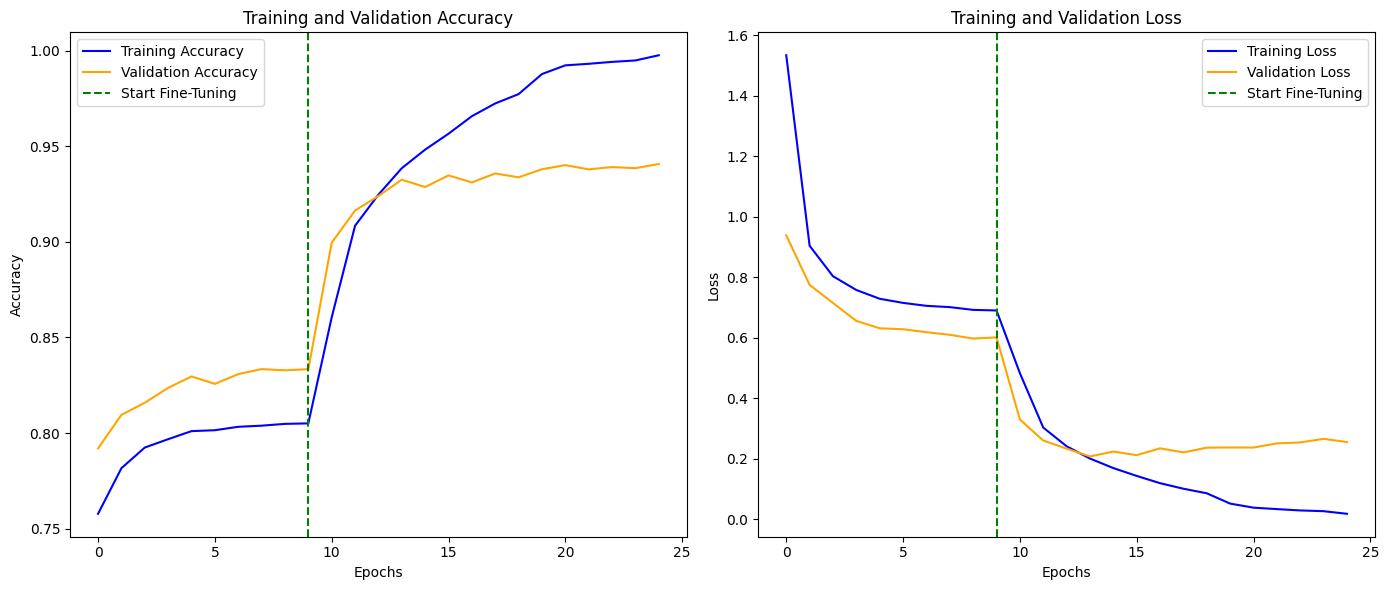

In [198]:
# 10. Plot Accuracy and Loss Curves
acc = hres020l.history['accuracy'] + historyfineres20l.history['accuracy']
val_acc = hres020l.history['val_accuracy'] + historyfineres20l.history['val_accuracy']

loss = hres020l.history['loss'] + historyfineres20l.history['loss']
val_loss = hres020l.history['val_loss'] + historyfineres20l.history['val_loss']

initial_epochs = len(hres020l.history['accuracy'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.savefig('resnet50/training_loss_curve.png', dpi=300)
plt.show()


In [18]:
# Extract true labels from the validation dataset
y_true = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)
y_true = np.argmax(y_true, axis=1)

# Generate predictions
y_pred_probs = resnet0.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Verify unique classes in y_true and y_pred
unique_y_true = np.unique(y_true)
unique_y_pred = np.unique(y_pred)

print(f"Unique classes in y_true: {unique_y_true}")
print(f"Unique classes in y_pred: {unique_y_pred}")

832/832 [==============================] - 25s 30ms/step
Unique classes in y_true: [0 1 2 3 4 5 6 7 8]
Unique classes in y_pred: [0 1 2 3 4 5 6 7 8]


In [180]:
# Define all labels
labels = list(range(len(class_names)))  # [0, 1, 2, ..., 8]

# Generate classification report with specified labels
report = classification_report(
    y_true, 
    y_pred, 
    target_names=class_names, 
    labels=labels,
    zero_division=0  # To handle divisions by zero gracefully
)

print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

      Center       0.94      0.95      0.95      3023
       Donut       0.99      0.98      0.99      3000
    Edge-Loc       0.87      0.87      0.87      3000
   Edge-Ring       0.98      0.98      0.98      3000
         Loc       0.84      0.82      0.83      3000
   Near-full       1.00      1.00      1.00      3000
      Random       0.98      0.99      0.99      3000
     Scratch       0.94      0.94      0.94      3000
        none       0.92      0.94      0.93      2600

    accuracy                           0.94     26623
   macro avg       0.94      0.94      0.94     26623
weighted avg       0.94      0.94      0.94     26623



In [181]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")  

Accuracy: 0.9408


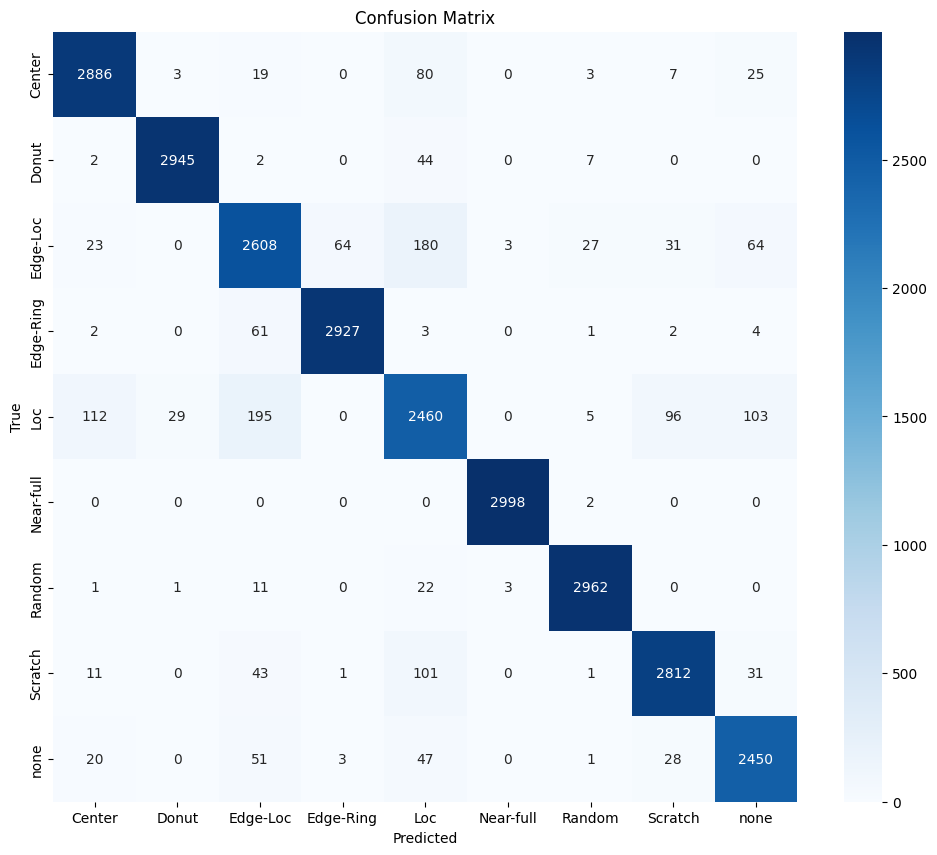

In [199]:
# 13. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('resnet50/confusionmatrix.png', dpi=300)
plt.show()


In [183]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


C:\Users\User\AppData\Local\Temp\ipykernel_5704\2849545318.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20').colors


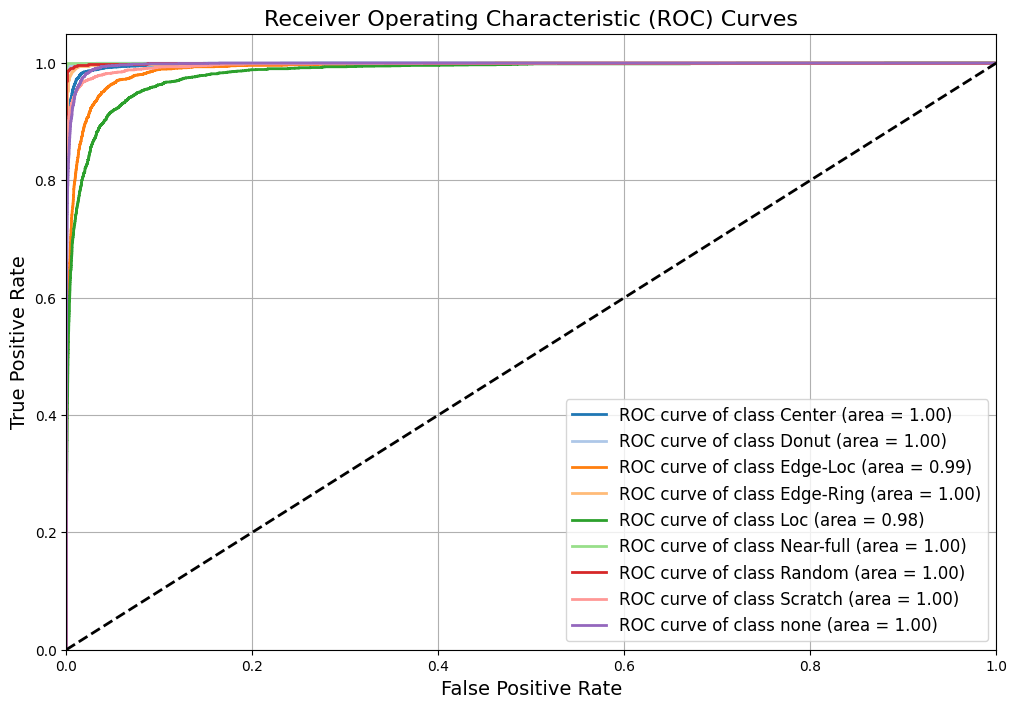

In [200]:
# 14. ROC Curves
y_true_binarized = label_binarize(y_true, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab20').colors

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             lw=2, label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.savefig('resnet50/roccurve.png', dpi=300)
plt.show()


In [185]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

labels = sorted(list(set(y_true)))  # Ensure all classes are included
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)



In [186]:
per_class_accuracy = {}
total_instances = np.sum(cm)

for i, label in enumerate(labels):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = total_instances - (TP + FP + FN)
    accuracy = (TP + TN) / total_instances
    per_class_accuracy[label] = accuracy


In [187]:
# Generate the classification report without support
report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose().drop(columns=['support'])

# Add Per-Class Accuracy
accuracy_series = pd.Series(per_class_accuracy, name='accuracy')
report_df = report_df.join(accuracy_series)

# Reorder columns if desired
report_df = report_df[['precision', 'recall', 'f1-score', 'accuracy']]

# Round for better readability
report_df = report_df.round(2)

print(report_df)


              precision  recall  f1-score  accuracy
0                  0.94    0.95      0.95       NaN
1                  0.99    0.98      0.99       NaN
2                  0.87    0.87      0.87       NaN
3                  0.98    0.98      0.98       NaN
4                  0.84    0.82      0.83       NaN
5                  1.00    1.00      1.00       NaN
6                  0.98    0.99      0.99       NaN
7                  0.94    0.94      0.94       NaN
8                  0.92    0.94      0.93       NaN
accuracy           0.94    0.94      0.94       NaN
macro avg          0.94    0.94      0.94       NaN
weighted avg       0.94    0.94      0.94       NaN


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')  # 'micro' or 'weighted' also possible
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9326
Precision: 0.9313
Recall: 0.9329
F1 Score: 0.9317


In [6]:
from tensorflow.keras.models import load_model

# Specify the path to your ResNet model file
model_path = "resnetbest20l.keras"

# Load the model
resnet0 = load_model(model_path)


In [9]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Class names
class_names = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
num_classes = len(class_names)

# Get the true labels and predicted labels
def get_predictions_and_labels(dataset, model):
    y_true = []
    predicted_labels = []

    for images, labels in dataset:
        # Predict the batch
        predictions = model.predict(images, verbose=0)
        predicted_labels.extend(np.argmax(predictions, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(y_true), np.array(predicted_labels)

# Get the true labels and predicted labels
y_true, predicted_labels = get_predictions_and_labels(val_dataset, resnet0)

# Calculate metrics for each class
class_accuracies = []
class_precisions = []
class_recalls = []
class_f1_scores = []

for class_index in range(num_classes):
    y_true_binary = (y_true == class_index).astype(int)
    predictions_binary = (predicted_labels == class_index).astype(int)

    class_accuracy = accuracy_score(y_true_binary, predictions_binary)
    class_precision = precision_score(y_true_binary, predictions_binary, zero_division=0)
    class_recall = recall_score(y_true_binary, predictions_binary, zero_division=0)
    class_f1_score = f1_score(y_true_binary, predictions_binary, zero_division=0)

    class_accuracies.append(class_accuracy)
    class_precisions.append(class_precision)
    class_recalls.append(class_recall)
    class_f1_scores.append(class_f1_score)

# Print the metrics for each class
for class_index, class_name in enumerate(class_names):
    print(f"Class '{class_name}' Metrics:")
    print(f"  Accuracy : {class_accuracies[class_index]:.4f}")
    print(f"  Precision: {class_precisions[class_index]:.4f}")
    print(f"  Recall   : {class_recalls[class_index]:.4f}")
    print(f"  F1-score : {class_f1_scores[class_index]:.4f}")
    print('-' * 50)


Class 'Center' Metrics:
  Accuracy : 0.9859
  Precision: 0.9346
  Recall   : 0.9414
  F1-score : 0.9380
--------------------------------------------------
Class 'Donut' Metrics:
  Accuracy : 0.9953
  Precision: 0.9758
  Recall   : 0.9830
  F1-score : 0.9794
--------------------------------------------------
Class 'Edge-Loc' Metrics:
  Accuracy : 0.9677
  Precision: 0.8562
  Recall   : 0.8577
  F1-score : 0.8570
--------------------------------------------------
Class 'Edge-Ring' Metrics:
  Accuracy : 0.9938
  Precision: 0.9671
  Recall   : 0.9787
  F1-score : 0.9728
--------------------------------------------------
Class 'Loc' Metrics:
  Accuracy : 0.9577
  Precision: 0.8472
  Recall   : 0.7617
  F1-score : 0.8022
--------------------------------------------------
Class 'Near-full' Metrics:
  Accuracy : 0.9993
  Precision: 0.9963
  Recall   : 0.9977
  F1-score : 0.9970
--------------------------------------------------
Class 'Random' Metrics:
  Accuracy : 0.9964
  Precision: 0.9837
  

In [190]:
############## Grad CAM ###########################

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.models import Model

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates a Grad-CAM heatmap for a given image and model.

    Parameters:
    - img_array: Preprocessed image array.
    - model: Trained CNN model.
    - last_conv_layer_name: Name of the last convolutional layer in the model.
    - pred_index: Index of the target class. If None, uses the predicted class.

    Returns:
    - heatmap: Generated heatmap as a NumPy array.
    """
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    return heatmap

def overlay_heatmap_on_image(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlays the Grad-CAM heatmap on the original image.

    Parameters:
    - img: Original image as a NumPy array.
    - heatmap: Generated heatmap as a NumPy array.
    - alpha: Transparency factor for the heatmap.
    - colormap: OpenCV colormap to apply to the heatmap.

    Returns:
    - heatmap_colored: Colored heatmap.
    - superimposed_img: Original image with heatmap overlay.
    """
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, colormap)
    superimposed_img = heatmap_colored * alpha + img

    return heatmap_colored, superimposed_img.astype('uint8')

def save_gradcam_visualizations(val_dataset, model, last_conv_layer_name, class_names, save_dir, num_samples_per_class=3):
    """
    Generates and saves Grad-CAM visualizations for multiple samples from the validation dataset.

    Parameters:
    - val_dataset: Validation dataset.
    - model: Trained CNN model.
    - last_conv_layer_name: Name of the last convolutional layer in the model.
    - class_names: List of class names corresponding to label indices.
    - save_dir: Directory to save the visualization images.
    - num_samples_per_class: Number of samples to visualize per class.
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # Create subdirectories for organized storage
    for class_name in class_names:
        class_dir = os.path.join(save_dir, class_name)
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)

    # Iterate over the validation dataset
    for batch in val_dataset:
        images, labels = batch
        preds = model.predict(images)
        pred_classes = np.argmax(preds, axis=1)
        true_classes = np.argmax(labels.numpy(), axis=1)

        for i in range(images.shape[0]):
            true_class = true_classes[i]
            pred_class = pred_classes[i]
            img = images[i].numpy()
            img_uint8 = (img * 255).astype('uint8') if img.max() <= 1.0 else img.astype('uint8')

            # Expand dimensions and preprocess the image
            img_array = np.expand_dims(img, axis=0)
            preprocessed_img = tf.keras.applications.resnet50.preprocess_input(img_array.copy())

            # Generate heatmap
            heatmap = make_gradcam_heatmap(preprocessed_img, model, last_conv_layer_name)

            # Overlay heatmap
            heatmap_colored, superimposed_img = overlay_heatmap_on_image(img_uint8, heatmap)

            # Determine if the prediction is correct
            is_correct = (pred_class == true_class)

            # Select samples based on correctness and desired number per class
            class_name = class_names[true_class]
            class_dir = os.path.join(save_dir, class_name)
            existing_files = len(os.listdir(class_dir))
            if existing_files >= num_samples_per_class:
                continue  # Skip if already have enough samples for this class

            # Plot and save the images
            plt.figure(figsize=(15, 5))

            plt.subplot(1, 3, 1)
            plt.imshow(img_uint8)
            plt.title(f"Original Image\nTrue: {class_names[true_class]}")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(heatmap, cmap='jet')
            plt.title("Grad-CAM Heatmap")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(superimposed_img)
            plt.title(f"Overlay\nPred: {class_names[pred_class]}")
            plt.axis('off')

            plt.tight_layout()
            sample_filename = f"{class_name}_sample_{existing_files + 1}.png"
            plt.savefig(os.path.join(class_dir, sample_filename))
            plt.close()

            # Stop if all classes have enough samples
            if all([len(os.listdir(os.path.join(save_dir, cls))) >= num_samples_per_class for cls in class_names]):
                break
        else:
            continue
        break  # Exit outer loop if enough samples collected

def save_misclassified_gradcam(val_dataset, model, last_conv_layer_name, class_names, save_dir, num_samples=3):
    """
    Generates and saves Grad-CAM visualizations for misclassified samples.

    Parameters:
    - val_dataset: Validation dataset.
    - model: Trained CNN model.
    - last_conv_layer_name: Name of the last convolutional layer in the model.
    - class_names: List of class names corresponding to label indices.
    - save_dir: Directory to save the visualization images.
    - num_samples: Number of misclassified samples to visualize.
    """
    misclassified_dir = os.path.join(save_dir, "misclassified")
    if not os.path.exists(misclassified_dir):
        os.makedirs(misclassified_dir)

    count = 0

    for batch in val_dataset:
        images, labels = batch
        preds = model.predict(images)
        pred_classes = np.argmax(preds, axis=1)
        true_classes = np.argmax(labels.numpy(), axis=1)

        for i in range(images.shape[0]):
            if pred_classes[i] != true_classes[i]:
                true_class = true_classes[i]
                pred_class = pred_classes[i]
                img = images[i].numpy()
                img_uint8 = (img * 255).astype('uint8') if img.max() <= 1.0 else img.astype('uint8')

                # Expand dimensions and preprocess the image
                img_array = np.expand_dims(img, axis=0)
                preprocessed_img = tf.keras.applications.resnet50.preprocess_input(img_array.copy())

                # Generate heatmap
                heatmap = make_gradcam_heatmap(preprocessed_img, model, last_conv_layer_name)

                # Overlay heatmap
                heatmap_colored, superimposed_img = overlay_heatmap_on_image(img_uint8, heatmap)

                # Plot and save the images
                plt.figure(figsize=(15, 5))

                plt.subplot(1, 3, 1)
                plt.imshow(img_uint8)
                plt.title(f"Original Image\nTrue: {class_names[true_class]}")
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.imshow(heatmap, cmap='jet')
                plt.title("Grad-CAM Heatmap")
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.imshow(superimposed_img)
                plt.title(f"Overlay\nPred: {class_names[pred_class]}")
                plt.axis('off')

                plt.tight_layout()
                sample_filename = f"misclassified_sample_{count + 1}.png"
                plt.savefig(os.path.join(misclassified_dir, sample_filename))
                plt.close()

                count += 1
                if count >= num_samples:
                    return  # Stop after saving the desired number of misclassified samples

def save_confidence_based_gradcam(val_dataset, model, last_conv_layer_name, class_names, save_dir, confidence_threshold=0.9, num_samples=3):
    """
    Generates and saves Grad-CAM visualizations for samples with high and low prediction confidence.

    Parameters:
    - val_dataset: Validation dataset.
    - model: Trained CNN model.
    - last_conv_layer_name: Name of the last convolutional layer in the model.
    - class_names: List of class names corresponding to label indices.
    - save_dir: Directory to save the visualization images.
    - confidence_threshold: Threshold to classify high and low confidence predictions.
    - num_samples: Number of samples per category to visualize.
    """
    high_conf_dir = os.path.join(save_dir, "high_confidence")
    low_conf_dir = os.path.join(save_dir, "low_confidence")
    os.makedirs(high_conf_dir, exist_ok=True)
    os.makedirs(low_conf_dir, exist_ok=True)

    high_count = 0
    low_count = 0

    for batch in val_dataset:
        images, labels = batch
        preds = model.predict(images)
        pred_probs = np.max(preds, axis=1)
        pred_classes = np.argmax(preds, axis=1)
        true_classes = np.argmax(labels.numpy(), axis=1)

        for i in range(images.shape[0]):
            prob = pred_probs[i]
            if prob >= confidence_threshold:
                category = "high_confidence"
                dir_path = high_conf_dir
            elif prob <= (1 - confidence_threshold):
                category = "low_confidence"
                dir_path = low_conf_dir
            else:
                continue  # Skip if not in high or low confidence

            if category == "high_confidence" and high_count >= num_samples:
                continue
            if category == "low_confidence" and low_count >= num_samples:
                continue

            true_class = true_classes[i]
            pred_class = pred_classes[i]
            img = images[i].numpy()
            img_uint8 = (img * 255).astype('uint8') if img.max() <= 1.0 else img.astype('uint8')

            # Expand dimensions and preprocess the image
            img_array = np.expand_dims(img, axis=0)
            preprocessed_img = tf.keras.applications.resnet50.preprocess_input(img_array.copy())

            # Generate heatmap
            heatmap = make_gradcam_heatmap(preprocessed_img, model, last_conv_layer_name)

            # Overlay heatmap
            heatmap_colored, superimposed_img = overlay_heatmap_on_image(img_uint8, heatmap)

            # Plot and save the images
            plt.figure(figsize=(15, 5))

            plt.subplot(1, 3, 1)
            plt.imshow(img_uint8)
            plt.title(f"Original Image\nTrue: {class_names[true_class]}")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(heatmap, cmap='jet')
            plt.title("Grad-CAM Heatmap")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(superimposed_img)
            plt.title(f"Overlay\nPred: {class_names[pred_class]}\nConfidence: {prob:.2f}")
            plt.axis('off')

            plt.tight_layout()
            sample_filename = f"{category}_sample_{high_count + 1 if category == 'high_confidence' else low_count + 1}.png"
            plt.savefig(os.path.join(dir_path, sample_filename))
            plt.close()

            if category == "high_confidence":
                high_count += 1
            else:
                low_count += 1

            if high_count >= num_samples and low_count >= num_samples:
                return  # Stop after saving the desired number of samples

In [8]:
# Example usage:
if __name__ == "__main__":
    # Assuming you have:
    # - val_dataset: your validation dataset
    # - resnet0: your trained ResNet50 model
    # - class_names: list of class names corresponding to your labels

    # Define class names
    class_names = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

    # Step 1: Find the last convolutional layer in ResNet50
    for layer in reversed(resnet0.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break

    print(f"Last convolutional layer: {last_conv_layer_name}")

    # Step 2: Specify directory to save the visualizations
    save_dir = 'gradcam_visualizations_paperrs'

    # Step 3: Generate and save Grad-CAM visualizations for each class
    save_gradcam_visualizations(
        val_dataset=val_dataset,
        model=resnet0,
        last_conv_layer_name=last_conv_layer_name,
        class_names=class_names,
        save_dir=save_dir,
        num_samples_per_class=3  # Adjust as needed
    )

    print("Grad-CAM visualizations for each class have been saved.")

    # Step 4: Generate and save Grad-CAM visualizations for misclassified samples
    save_misclassified_gradcam(
        val_dataset=val_dataset,
        model=resnet0,
        last_conv_layer_name=last_conv_layer_name,
        class_names=class_names,
        save_dir=save_dir,
        num_samples=3  # Adjust as needed
    )

    print("Grad-CAM visualizations for misclassified samples have been saved.")

    # Step 5: Generate and save Grad-CAM visualizations based on confidence levels
    save_confidence_based_gradcam(
        val_dataset=val_dataset,
        model=resnet0,
        last_conv_layer_name=last_conv_layer_name,
        class_names=class_names,
        save_dir=save_dir,
        confidence_threshold=0.9,  # Adjust as needed
        num_samples=3  # Adjust as needed
    )

    print("Grad-CAM visualizations based on confidence levels have been saved.")

Last convolutional layer: conv5_block3_3_conv
1/1 [==============================] - 0s 31ms/step
Grad-CAM visualizations for each class have been saved.
1/1 [==============================] - 0s 22ms/step
Grad-CAM visualizations for misclassified samples have been saved.
1/1 [==============================] - 1s 659ms/step
Grad-CAM visualizations based on confidence levels have been saved.


In [193]:
################### 2nd gradcam #####################
def save_layer_wise_gradcam(val_dataset, model, conv_layer_names, class_names, save_dir, num_samples=1):
    """
    Generates and saves layer-wise Grad-CAM visualizations for specified convolutional layers.

    Parameters:
    - val_dataset: Validation dataset.
    - model: Trained CNN model.
    - conv_layer_names: List of convolutional layer names to visualize.
    - class_names: List of class names corresponding to label indices.
    - save_dir: Directory to save the visualization images.
    - num_samples: Number of samples to visualize.
    """
    layer_dir = os.path.join(save_dir, "layer_wise_gradcam")
    os.makedirs(layer_dir, exist_ok=True)

    for layer_name in conv_layer_names:
        layer_specific_dir = os.path.join(layer_dir, layer_name)
        os.makedirs(layer_specific_dir, exist_ok=True)

    sample_count = 0

    for batch in val_dataset:
        images, labels = batch
        preds = model.predict(images)
        pred_classes = np.argmax(preds, axis=1)

        for i in range(images.shape[0]):
            img = images[i].numpy()
            img_uint8 = (img * 255).astype('uint8') if img.max() <= 1.0 else img.astype('uint8')

            # Expand dimensions and preprocess the image
            img_array = np.expand_dims(img, axis=0)
            preprocessed_img = tf.keras.applications.resnet50.preprocess_input(img_array.copy())

            # Predict class
            pred_class = pred_classes[i]

            for layer_name in conv_layer_names:
                # Generate heatmap
                heatmap = make_gradcam_heatmap(preprocessed_img, model, layer_name, pred_index=pred_class)

                # Overlay heatmap
                heatmap_colored, superimposed_img = overlay_heatmap_on_image(img_uint8, heatmap)

                # Plot and save the images
                plt.figure(figsize=(15, 5))

                plt.subplot(1, 3, 1)
                plt.imshow(img_uint8)
                plt.title(f"Original Image\nPred: {class_names[pred_class]}")
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.imshow(heatmap, cmap='jet')
                plt.title(f"Grad-CAM Heatmap\nLayer: {layer_name}")
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.imshow(superimposed_img)
                plt.title(f"Overlay\nLayer: {layer_name}")
                plt.axis('off')

                plt.tight_layout()
                sample_filename = f"{layer_name}_sample_{sample_count + 1}.png"
                plt.savefig(os.path.join(layer_specific_dir, sample_filename))
                plt.close()

            sample_count += 1
            if sample_count >= num_samples:
                return  # Stop after saving the desired number of samples


In [195]:
# Define the convolutional layers you want to visualize
conv_layer_names = [
    'conv5_block3_out',  # Final block of conv5
    'conv4_block6_out',  # Final block of conv4
    'conv3_block4_out',  # Final block of conv3 (added)
    'conv2_block3_out'   # Final block of conv2 (added)
]  # Replace these with actual layer names if different in your ResNet50 model

# Save layer-wise Grad-CAM visualizations
save_layer_wise_gradcam(
    val_dataset=val_dataset,
    model=resnet0,
    conv_layer_names=conv_layer_names,
    class_names=class_names,
    save_dir=save_dir,
    num_samples=2  # Adjust as needed
)

print("Layer-wise Grad-CAM visualizations have been saved.")


1/1 [==============================] - 0s 16ms/step
Layer-wise Grad-CAM visualizations have been saved.


In [3]:
########################################## Efficient Net B3 ###################################################

from tensorflow.keras.applications import InceptionV3

# Load InceptionV3 base model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))  # InceptionV3 uses 299x299 input size
base_model.trainable = False  # Freeze the base model initially

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)  # Dropout to reduce overfitting
x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)
predictions = Dense(len(train_dataset.class_names), activation='softmax')(x)

# Create the final model
inception_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
inception_model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# Compute class weights to handle class imbalance
y_train_classes = np.concatenate([y.numpy() for _, y in train_dataset])
y_train_labels = np.argmax(y_train_classes, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights))

# Callbacks for training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint('inceptionbest.keras', monitor='val_loss', save_best_only=True, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]


In [4]:
# Train only the top layers (before fine-tuning)
history_initial = inception_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10
3328/3328 [==============================] - 157s 45ms/step - loss: 1.8943 - accuracy: 0.7198 - val_loss: 0.9906 - val_accuracy: 0.7618 - lr: 0.0010
Epoch 2/10
3328/3328 [==============================] - 150s 45ms/step - loss: 0.9790 - accuracy: 0.7556 - val_loss: 0.8164 - val_accuracy: 0.7881 - lr: 0.0010
Epoch 3/10
3328/3328 [==============================] - 151s 45ms/step - loss: 0.8639 - accuracy: 0.7705 - val_loss: 0.7556 - val_accuracy: 0.7980 - lr: 0.0010
Epoch 4/10
3328/3328 [==============================] - 150s 45ms/step - loss: 0.8207 - accuracy: 0.7766 - val_loss: 0.7034 - val_accuracy: 0.8137 - lr: 0.0010
Epoch 5/10
3328/3328 [==============================] - 151s 45ms/step - loss: 0.7933 - accuracy: 0.7801 - val_loss: 0.6936 - val_accuracy: 0.8106 - lr: 0.0010
Epoch 6/10
3328/3328 [==============================] - 151s 45ms/step - loss: 0.7833 - accuracy: 0.7811 - val_loss: 0.6976 - val_accuracy: 0.8093 - lr: 0.0010
Epoch 7/10
3328/3328 [==================

In [6]:
from tensorflow.keras.models import load_model

# Specify the path to your ResNet model file
model_path = "inceptionbest.keras"

# Load the model
inception_model= load_model(model_path)

In [9]:
# Unfreeze some layers in the base model for fine-tuning
base_model.trainable = True
# Freeze all layers except the last 5
for layer in base_model.layers[:-15]:
    layer.trainable = False

# Recompile the model with a lower learning rate for fine-tuning
inception_model.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Fine-tune the model
hincepfine = inception_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=2,
    # Remove batch_size if train_aug_dataset is already batched
    callbacks=callbacks,
    class_weight=class_weights
)

# Evaluate on the test dataset
test_loss, test_accuracy = inception_model.evaluate(val_dataset)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")


Epoch 1/2
3328/3328 [==============================] - 156s 46ms/step - loss: 0.3659 - accuracy: 0.8802 - val_loss: 0.3618 - val_accuracy: 0.8801 - lr: 1.0000e-04
Epoch 2/2
832/832 [==============================] - 29s 35ms/step - loss: 0.3362 - accuracy: 0.8889


NameError: name 'val_accuracy' is not defined

In [10]:
# Extract true labels from the validation dataset
y_true = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)
y_true = np.argmax(y_true, axis=1)

# Generate predictions
y_pred_probs = inception_model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Verify unique classes in y_true and y_pred
unique_y_true = np.unique(y_true)
unique_y_pred = np.unique(y_pred)

print(f"Unique classes in y_true: {unique_y_true}")
print(f"Unique classes in y_pred: {unique_y_pred}")


832/832 [==============================] - 28s 33ms/step
Unique classes in y_true: [0 1 2 3 4 5 6 7 8]
Unique classes in y_pred: [0 1 2 3 4 5 6 7 8]


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')  # 'micro' or 'weighted' also possible
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8889
Precision: 0.8917
Recall: 0.8895
F1 Score: 0.8883


In [15]:
import pickle
# Save the history with pickle
with open('historyincepinit.pkl', 'wb') as f:
    pickle.dump(history_initial.history, f)

with open('historyincepfine.pkl', 'wb') as f:
    pickle.dump(hincepfine.history, f)

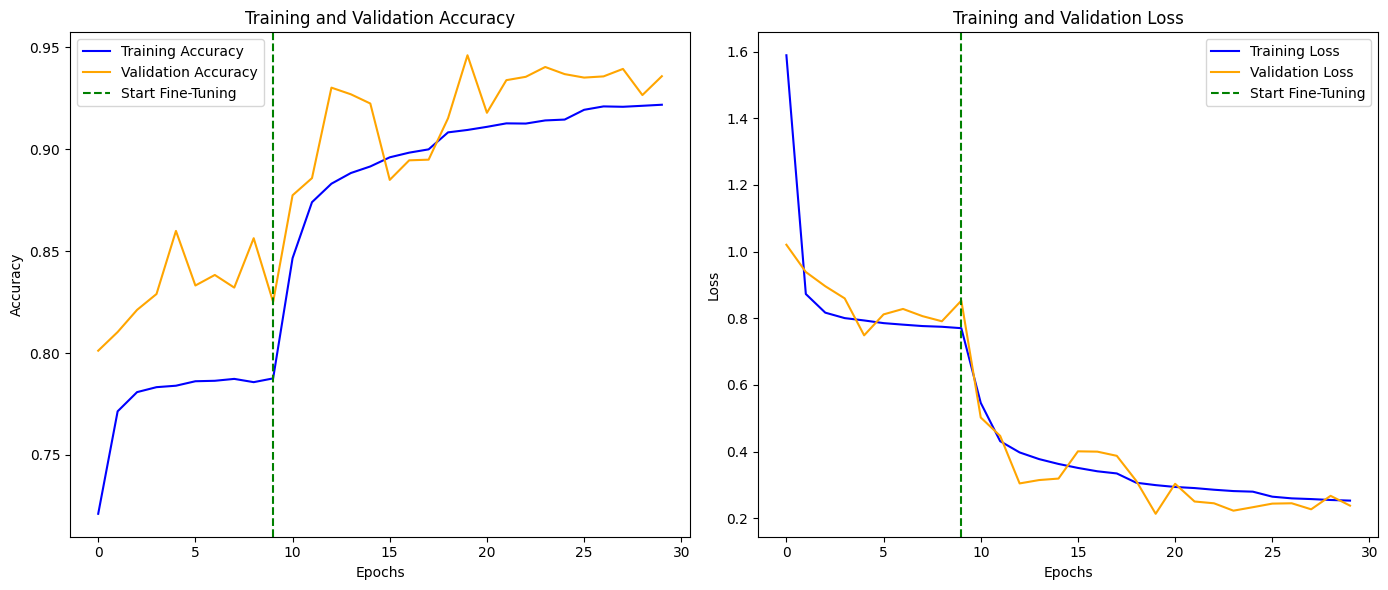

In [16]:
# 10. Plot Accuracy and Loss Curves
acc = history_initial.history['accuracy'] + hincepfine.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + hincepfine.history['val_accuracy']

loss = history_initial.history['loss'] + hincepfine.history['loss']
val_loss = history_initial.history['val_loss'] + hincepfine.history['val_loss']

initial_epochs = len(history_initial.history['accuracy'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
###############################       FINAL VISUALIZATION #########################################

In [50]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
####################################   CUSTOM MODEL #############################################

test_loss, test_accuracy = modelcustom.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

1065/1065 [==============================] - 15s 14ms/step - loss: 0.1932 - accuracy: 0.9534
Test Loss: 0.1932, Test Accuracy: 0.9534


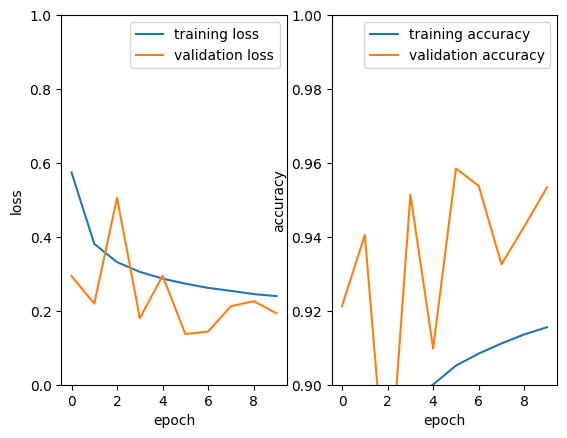

In [33]:
plt.subplot(1,2,1)
plt.plot(hcustom.history['loss'])
plt.plot(hcustom.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.ylim([0, 1])
plt.legend(['training loss', 'validation loss'])

plt.subplot(1,2,2)
plt.plot(hcustom.history['accuracy'])
plt.plot(hcustom.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.ylim([0.9, 1])
plt.legend(['training accuracy', 'validation accuracy'])
#plt.savefig('CUSTOM_training_loss_curve.png', dpi=300)

In [36]:
class_names = train_aug_dataset.class_names
from sklearn.metrics import classification_report

In [90]:
# 11. Generate Predictions
y_true = np.concatenate([y.numpy() for x, y in train_aug_dataset], axis=0)
y_pred_probs = modelcustom.predict(train_aug_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_true, axis=1)

# 12. Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

4717/4717 [==============================] - 63s 13ms/step


ValueError: Number of classes, 9, does not match size of target_names, 8. Try specifying the labels parameter

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1-Score (macro, micro, or weighted averaging)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
# Print Results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")
print("\nClassification Report:\n", report)

Accuracy: 0.7569
Precision (Macro): 0.1124
Recall (Macro): 0.1124
F1-Score (Macro): 0.1119

Classification Report:
               precision    recall  f1-score   support

      Center       0.03      0.03      0.03      2738
       Donut       0.01      0.01      0.01       355
    Edge-Loc       0.03      0.02      0.02      3227
   Edge-Ring       0.06      0.06      0.06      6182
         Loc       0.03      0.01      0.02      2249
   Near-full       0.00      0.00      0.00        95
      Random       0.01      0.01      0.01       550
     Scratch       0.00      0.00      0.00       742
        none       0.85      0.88      0.87     92818

    accuracy                           0.76    108956
   macro avg       0.11      0.11      0.11    108956
weighted avg       0.73      0.76      0.74    108956



In [43]:
###################################### INCEPTION V3 #########################################

# 9. Evaluate the Model
test_loss, test_accuracy = inception_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

1065/1065 [==============================] - 39s 36ms/step - loss: 0.2377 - accuracy: 0.9358
Test Loss: 0.2377, Test Accuracy: 0.9358


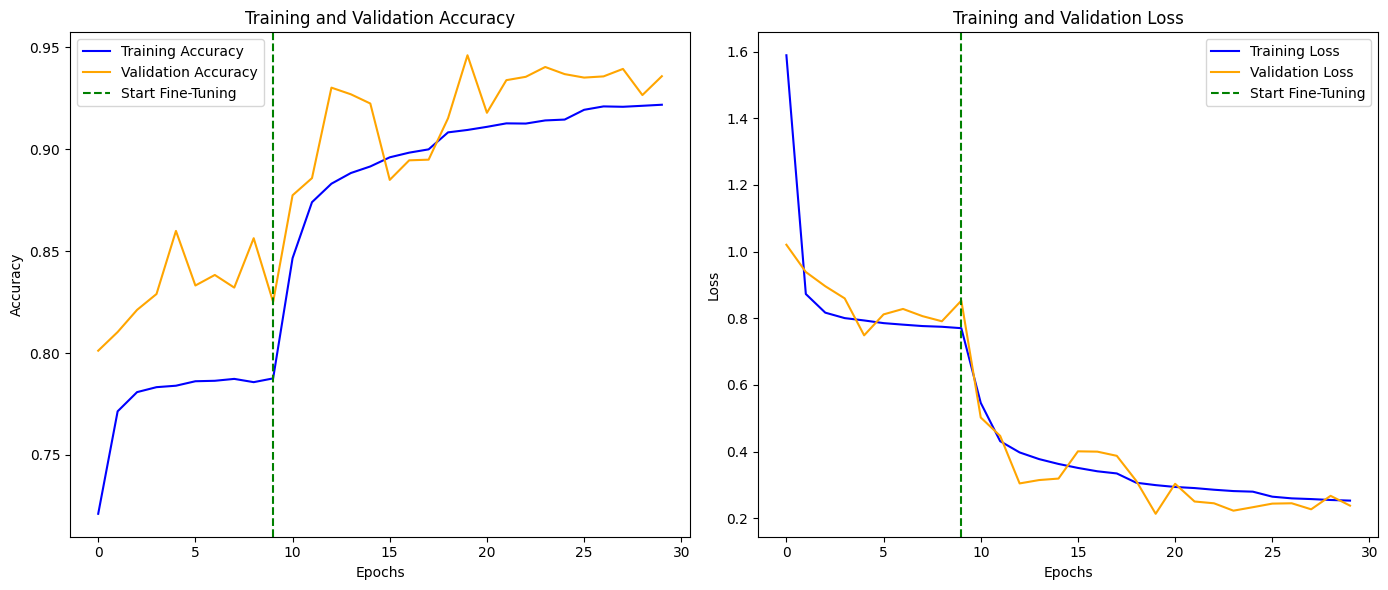

In [44]:
# 10. Plot Accuracy and Loss Curves
acc = history_initial.history['accuracy'] + hincepfine.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + hincepfine.history['val_accuracy']

loss = history_initial.history['loss'] + hincepfine.history['loss']
val_loss = history_initial.history['val_loss'] + hincepfine.history['val_loss']

initial_epochs = len(history_initial.history['accuracy'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# 11. Generate Predictions
y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0)
y_pred_probs = inception_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_true, axis=1)

# 12. Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

1065/1065 [==============================] - 38s 34ms/step
Classification Report:

              precision    recall  f1-score   support

      Center       0.03      0.03      0.03       856
       Donut       0.00      0.00      0.00       111
    Edge-Loc       0.03      0.05      0.04      1008
   Edge-Ring       0.06      0.06      0.06      1932
         Loc       0.02      0.03      0.02       703
   Near-full       0.00      0.00      0.00        30
      Random       0.02      0.02      0.02       172
     Scratch       0.01      0.01      0.01       232
        none       0.85      0.82      0.83     29006

    accuracy                           0.70     34050
   macro avg       0.11      0.11      0.11     34050
weighted avg       0.73      0.70      0.72     34050



In [47]:
# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1-Score (macro, micro, or weighted averaging)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
# Print Results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")

Accuracy: 0.7041
Precision (Macro): 0.1128
Recall (Macro): 0.1132
F1-Score (Macro): 0.1126


In [148]:
############################## Resnet50 #########################################
# 9. Evaluate the Model
test_loss, test_accuracy = resnet0.evaluate(validation_dataset)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

832/832 [==============================] - 27s 32ms/step - loss: 0.7391 - accuracy: 0.8146
Test Loss: 0.7391, Test Accuracy: 0.8146


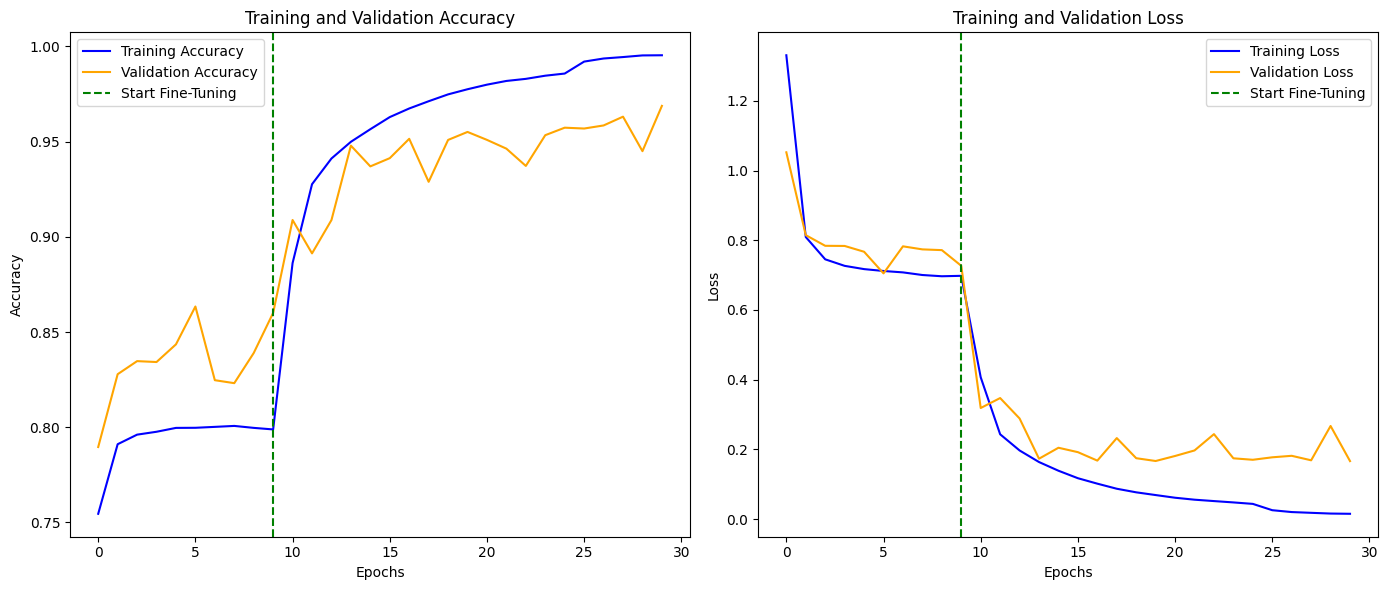

In [54]:
# 10. Plot Accuracy and Loss Curves
acc = hres020l.history['accuracy'] + historyfineres20l.history['accuracy']
val_acc = hres020l.history['val_accuracy'] + historyfineres20l.history['val_accuracy']

loss = hres020l.history['loss'] + historyfineres20l.history['loss']
val_loss = hres020l.history['val_loss'] + historyfineres20l.history['val_loss']

initial_epochs = len(hres020l.history['accuracy'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()



In [152]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")  

Accuracy: 0.8146


In [153]:
class_names = validation_dataset.class_names
class_names

['Center',
 'Donut',
 'Edge-Loc',
 'Edge-Ring',
 'Loc',
 'Near-full',
 'Random',
 'Scratch',
 'none']

In [151]:
y_true = np.concatenate([y.numpy() for x, y in validation_dataset], axis=0)
y_pred_probs = resnet0.predict(validation_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_true, axis=1)

# # 12. Classification Report
# report = classification_report(y_true, y_pred, target_names=class_names)
# print("Classification Report:\n")
# print(report)

832/832 [==============================] - 26s 30ms/step


In [155]:
# Assuming y_true and y_pred are NumPy arrays
unique_y_true = np.unique(y_true)
unique_y_pred = np.unique(y_pred)

print(f"Unique classes in y_true: {unique_y_true}")
print(f"Unique classes in y_pred: {unique_y_pred}")

Unique classes in y_true: [7 8]
Unique classes in y_pred: [0 1 2 3 4 6 7 8]


In [156]:

# Assuming y_true is a NumPy array of true labels (integer encoded)
unique, counts = np.unique(y_true, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution in y_true:")
for cls, count in class_distribution.items():
    print(f"Class {cls}: {count} samples")

Class distribution in y_true:
Class 7: 13623 samples
Class 8: 13000 samples


In [158]:
data_dir = 'WM811K_train_aug'  # Your augmented training data directory

# Initialize lists
file_paths = []
labels = []

# Iterate through each class subdirectory
for class_name in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, class_name)
    if os.path.isdir(class_dir):
        for file in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file)
            file_paths.append(file_path)
            labels.append(class_name)

# Create a DataFrame
df = pd.DataFrame({
    'file_path': file_paths,
    'label': labels
})

In [159]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Save class names mapping
class_names = label_encoder.classes_
print("Class Names:", list(class_names))

Class Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


In [160]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label_encoded'],
    random_state=42
)

print("Training set size:", len(train_df))
print("Validation set size:", len(val_df))


Training set size: 106492
Validation set size: 26623


In [161]:
import shutil

train_dir = 'WM811K_train_split'
val_dir = 'WM811K_val_split'

# Create directories if they don't exist
for class_name in class_names:
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

# Function to copy files
def copy_files(df_subset, destination_dir):
    for _, row in df_subset.iterrows():
        src = row['file_path']
        label = row['label']
        dst = os.path.join(destination_dir, label, os.path.basename(src))
        shutil.copy(src, dst)

# Copy training files
copy_files(train_df, train_dir)

# Copy validation files
copy_files(val_df, val_dir)

In [2]:
import tensorflow as tf
from tensorflow import keras

batch_size = 32
img_height = 224
img_width = 224
seed = 123
train_dir = 'WM811K_train_split'
val_dir = 'WM811K_val_split'
# Load Training Dataset
train_dataset = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=(img_height, img_width),
    shuffle=True,
    seed=seed
)

# Load Validation Dataset
val_dataset = keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=(img_height, img_width),
    shuffle=False,
    seed=seed
)

# Verify class names
print("Training Dataset Class Names:", train_dataset.class_names)
print("Validation Dataset Class Names:", val_dataset.class_names)


Found 106492 files belonging to 9 classes.
Found 26623 files belonging to 9 classes.
Training Dataset Class Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
Validation Dataset Class Names: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


In [163]:
# Count samples per class in validation set
val_class_counts = {}
for images, labels in val_dataset:
    labels_np = labels.numpy()
    for label in labels_np:
        class_idx = label.argmax()
        val_class_counts[class_idx] = val_class_counts.get(class_idx, 0) + 1

print("Validation Set Class Distribution:")
for class_idx, count in val_class_counts.items():
    print(f"Class {class_idx} ({val_dataset.class_names[class_idx]}): {count} samples")


Validation Set Class Distribution:
Class 0 (Center): 3023 samples
Class 1 (Donut): 3000 samples
Class 2 (Edge-Loc): 3000 samples
Class 3 (Edge-Ring): 3000 samples
Class 4 (Loc): 3000 samples
Class 5 (Near-full): 3000 samples
Class 6 (Random): 3000 samples
Class 7 (Scratch): 3000 samples
Class 8 (none): 2600 samples


In [165]:
# Extract true labels from the validation dataset
y_true = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)
y_true = np.argmax(y_true, axis=1)

# Generate predictions
y_pred_probs = resnet0.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Verify unique classes in y_true and y_pred
unique_y_true = np.unique(y_true)
unique_y_pred = np.unique(y_pred)

print(f"Unique classes in y_true: {unique_y_true}")
print(f"Unique classes in y_pred: {unique_y_pred}")


832/832 [==============================] - 25s 31ms/step
Unique classes in y_true: [0 1 2 3 4 5 6 7 8]
Unique classes in y_pred: [0 1 2 3 4 5 6 7 8]


In [166]:
# 12. Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

      Center       0.84      0.81      0.82      3023
       Donut       0.98      0.94      0.96      3000
    Edge-Loc       0.66      0.66      0.66      3000
   Edge-Ring       0.96      0.95      0.95      3000
         Loc       0.60      0.61      0.61      3000
   Near-full       0.99      1.00      1.00      3000
      Random       0.98      0.97      0.97      3000
     Scratch       0.92      0.80      0.85      3000
        none       0.67      0.84      0.75      2600

    accuracy                           0.84     26623
   macro avg       0.85      0.84      0.84     26623
weighted avg       0.85      0.84      0.84     26623



In [167]:
from sklearn.metrics import classification_report

# Define all labels
labels = list(range(len(class_names)))  # [0, 1, 2, ..., 8]

# Generate classification report with specified labels
report = classification_report(
    y_true, 
    y_pred, 
    target_names=class_names, 
    labels=labels,
    zero_division=0  # To handle divisions by zero gracefully
)

print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

      Center       0.84      0.81      0.82      3023
       Donut       0.98      0.94      0.96      3000
    Edge-Loc       0.66      0.66      0.66      3000
   Edge-Ring       0.96      0.95      0.95      3000
         Loc       0.60      0.61      0.61      3000
   Near-full       0.99      1.00      1.00      3000
      Random       0.98      0.97      0.97      3000
     Scratch       0.92      0.80      0.85      3000
        none       0.67      0.84      0.75      2600

    accuracy                           0.84     26623
   macro avg       0.85      0.84      0.84     26623
weighted avg       0.85      0.84      0.84     26623



In [143]:
from collections import Counter
pred_counts = Counter(y_pred)
print("Prediction Distribution:", pred_counts)

Prediction Distribution: Counter({8: 21921, 3: 1552, 2: 1518, 4: 963, 0: 814, 7: 196, 6: 149, 1: 102, 5: 25})


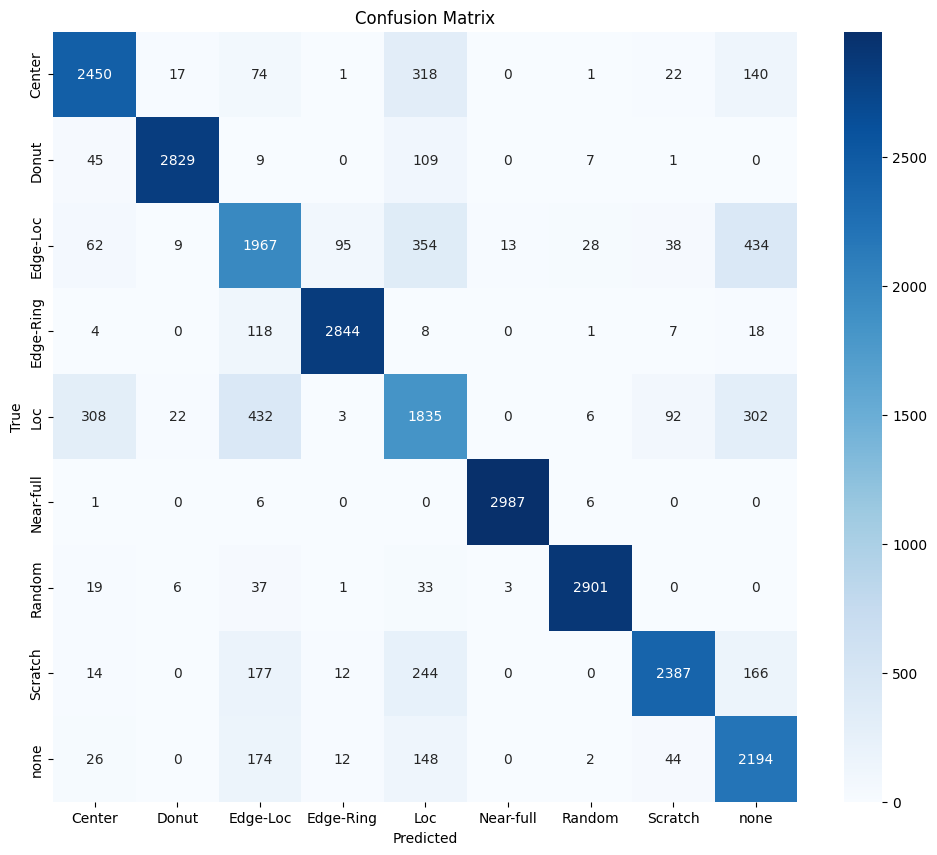

<Figure size 640x480 with 0 Axes>

In [169]:
# 13. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
plt.savefig('resinit.png')

In [171]:
#### for fine tuned resnet 
# Extract true labels from the validation dataset
y_true = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)
y_true = np.argmax(y_true, axis=1)

# Generate predictions
y_pred_probs = resnet0.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Verify unique classes in y_true and y_pred
unique_y_true = np.unique(y_true)
unique_y_pred = np.unique(y_pred)

print(f"Unique classes in y_true: {unique_y_true}")
print(f"Unique classes in y_pred: {unique_y_pred}")

832/832 [==============================] - 26s 31ms/step
Unique classes in y_true: [0 1 2 3 4 5 6 7 8]
Unique classes in y_pred: [0 1 2 3 4 5 6 7 8]


In [172]:
# Define all labels
labels = list(range(len(class_names)))  # [0, 1, 2, ..., 8]

# Generate classification report with specified labels
report = classification_report(
    y_true, 
    y_pred, 
    target_names=class_names, 
    labels=labels,
    zero_division=0  # To handle divisions by zero gracefully
)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

      Center       0.94      0.95      0.95      3023
       Donut       0.95      1.00      0.97      3000
    Edge-Loc       0.86      0.86      0.86      3000
   Edge-Ring       0.97      0.97      0.97      3000
         Loc       0.82      0.81      0.81      3000
   Near-full       1.00      1.00      1.00      3000
      Random       0.99      0.97      0.98      3000
     Scratch       0.95      0.92      0.94      3000
        none       0.93      0.93      0.93      2600

    accuracy                           0.93     26623
   macro avg       0.93      0.93      0.93     26623
weighted avg       0.93      0.93      0.93     26623



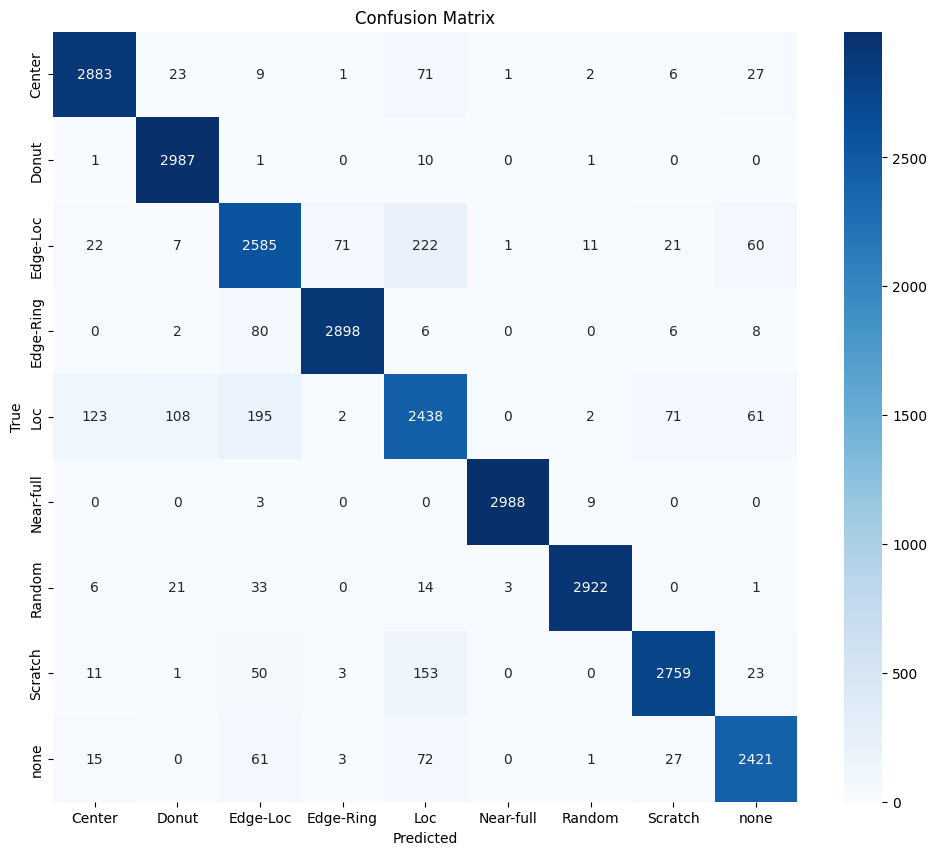

<Figure size 640x480 with 0 Axes>

In [174]:
# 13. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
plt.savefig('resfinetuned.png')

In [59]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


C:\Users\User\AppData\Local\Temp\ipykernel_5704\1730504511.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20').colors


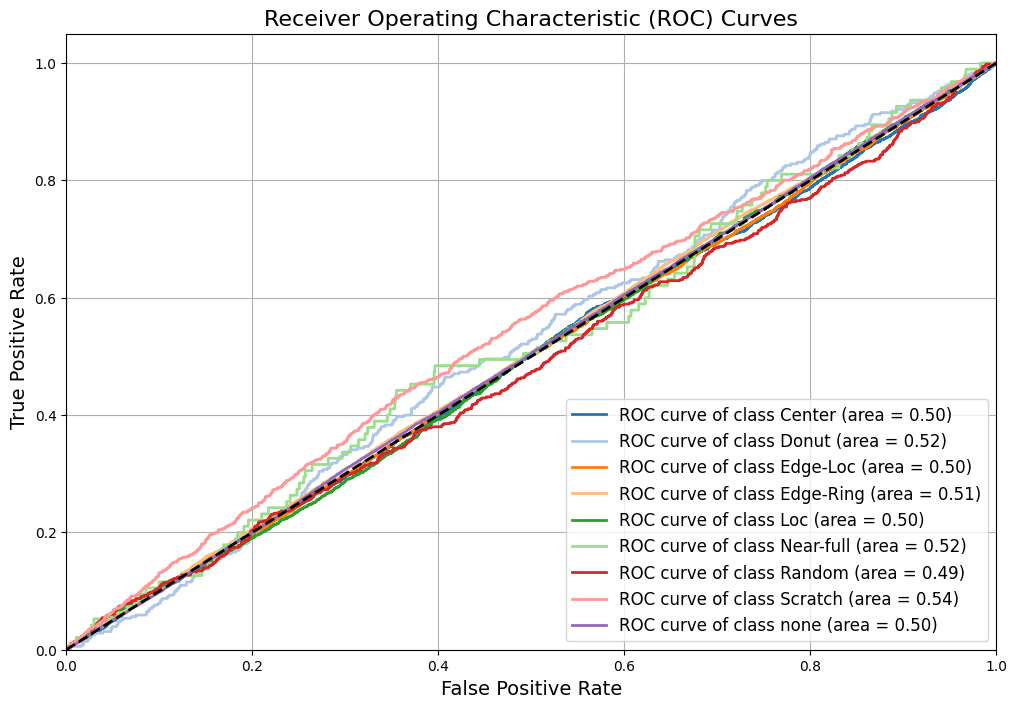

In [60]:
# 14. ROC Curves
y_true_binarized = label_binarize(y_true, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab20').colors

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             lw=2, label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()


In [61]:
# 15. Grad-CAM Implementation

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    return heatmap

def overlay_heatmap_on_tensor(img_tensor, heatmap, alpha=0.4):
    img = img_tensor.numpy().astype("uint8")
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img.astype('uint8'))
    plt.axis('off')
    plt.title('Grad-CAM')
    plt.show()

In [66]:
pip install opencv-python


   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.8 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.8 MB 5.6 MB/s eta 0:00:07
   -- ------------------------------------- 2.9/38.8 MB 5.8 MB/s eta 0:00:07
   ---- ----------------------------------- 4.7/38.8 MB 6.8 MB/s eta 0:00:06
   ------ --------------------------------- 6.0/38.8 MB 6.7 MB/s eta 0:00:05
   ------- -------------------------------- 6.8/38.8 MB 6.4 MB/s eta 0:00:06
   -------- ------------------------------- 8.1/38.8 MB 6.2 MB/s eta 0:00:05
   ---------- ----------------------------- 10.0/38.8 MB 6.6 MB/s eta 0:00:05
   ----------- ---------------------------- 11.3/38.8 MB 6.6 MB/s eta 0:00:05
   ------------- -------------------------- 13.1/38.8 MB 6.9 MB/s eta 0:00:04
   -------------- ------------------------- 14.4/38.8 MB 7.0 MB/s eta 0:00:04
   ---------------- ----------------------- 16.0/38.8 MB 6.8 MB/s eta 0:00:04
   -----

In [67]:
import cv2  # Import OpenCV
import numpy as np
import tensorflow as tf

Last convolutional layer: conv5_block3_3_conv


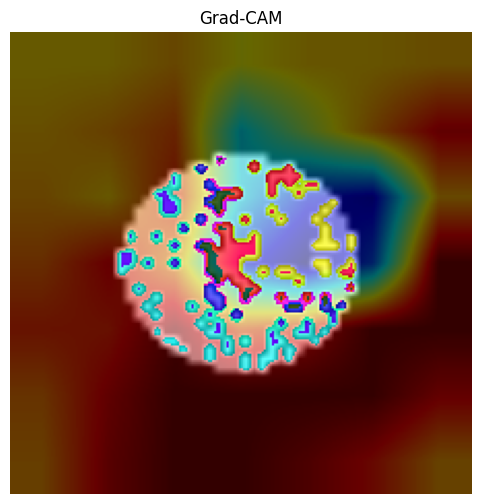

In [68]:
# Select a sample image from the test dataset
test_batch = next(iter(test_dataset))
test_images, test_labels = test_batch

image_index = 0  # Change this index to visualize different images
img = test_images[image_index]
label = np.argmax(test_labels[image_index])

# Expand dimensions
img_array = np.expand_dims(img, axis=0)

# Ensure the array is writable
img_array = img_array.copy()

# Preprocess the image for ResNet50
preprocessed_img = tf.keras.applications.resnet50.preprocess_input(img_array)

# Find the last convolutional layer in ResNet50
for layer in reversed(resnet0.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print(f"Last convolutional layer: {last_conv_layer_name}")
heatmap = make_gradcam_heatmap(preprocessed_img, resnet0, last_conv_layer_name)

# Overlay the heatmap
overlay_heatmap_on_tensor(img, heatmap)